`Note: Non-overlapping annual returns`

# Imports and Data Loading
First, we load the required packages and fetch the true target data (`y_true` and `dates`) for the KR dataset from 1971-08-31 to 2025-06-30.

In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

import utils.base_utils as bu
import utils.window_utils as wu

# Configure target series configuration matched to the orchestrator runs
start_date = '1971-08-31'
end_date = '2025-06-30'
OOS_start_idx = pd.Timestamp('1990-01-31')

# For KR yields (annual maturities, holding period = 12 months)
maturities = [str(i) for i in range(12, 121) if i % 12 == 0] 
yields = bu.get_yields(type='kr', start=start_date, end=end_date, maturities=maturities) # set to 'lw' for robustness!
xr = bu.get_excess_returns(yields, horizon=12).dropna()

# Standard selected 6 maturities modeled in orchestrator runs
target_maturities = ['24', '36', '48', '60', '84', '120']
y_true = xr[target_maturities].values
dates = xr.index

print(f"y_true shape: {y_true.shape}")
print(f"Dates range: {dates[0].strftime('%Y-%m-%d')} to {dates[-1].strftime('%Y-%m-%d')}")

recession_indicator_path = os.path.join(root_dir, 'data', 'USREC.csv')
recession_indicators = pd.read_csv(recession_indicator_path, index_col=0, parse_dates=True)

y_true shape: (635, 6)
Dates range: 1971-08-31 to 2024-06-30


## Load Orchestrator Runs

Here we pull the `val_loss` (or `trailing_oos`) ensemble forecasts for the two multi-output ANN specifications.

In [30]:
import json
# Paths to the specific orchestrated model runs
forward_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', 'fwd_ann_3&3_100runs_top10', '20260512_141546') 
# macro_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', 'realtime_kr_1971_08_2025_06_macro_fwd_ann_fwd333_macro32_100runs_top10', '20260430_040715') # realtime
# group_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', 'realtime_kr_1971_08_2025_06_group_ens_ann_fwd33_grp1_100runs_top10', '20260430_032808') # realtime
macro_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', 'revised_kr_1971_08_2025_06_macro_fwd_ann_fwd333_macro32_100runs_top10', '20260429_051214') # revised
group_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', 'revised_kr_1971_08_2025_06_group_ens_ann_fwd33_grp1_100runs_top10', '20260429_041039') # revised

# LW-specific paths for robustness
# forward_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', 'run_1971_2025_lw_ANNUAL_NONOVERLAPPING_revised', 'fwd_ann_3&3_100runs_top10', '20260602_101445') 
# macro_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', 'run_1971_2025_lw_ANNUAL_NONOVERLAPPING_realtime', 'macro_fwd_ann_fwd3&3&3_macro32_100runs_top10', '20260602_001909') # realtime
# group_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', 'run_1971_2025_lw_ANNUAL_NONOVERLAPPING_realtime', 'group_ens_ann_fwd3&3_grp1_100runs_top10', '20260602_045853') # realtime
# macro_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', 'run_1971_2025_lw_ANNUAL_NONOVERLAPPING_revised', 'macro_fwd_ann_fwd3&3&3_macro32_100runs_top10', '20260602_104734') # revised
# group_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', 'run_1971_2025_lw_ANNUAL_NONOVERLAPPING_revised', 'group_ens_ann_fwd3&3_grp1_100runs_top10', '20260601_225626') # revised

# 30-month tuning example:
# group_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', '30_month_tuning_run_1971_2025_kr_ANNUAL_NONOVERLAPPING_realtime', 'group_ens_ann_fwd3&3_grp1_100runs_top10', '20260604_003621') # realtime

from utils.orchestrator_runs import load_and_reensemble_run
from utils.orchestrator_utils import compute_top_k_ensemble as compute_trailing_top_k_ensemble

ENSEMBLE_K = 10
TRAILING_LOOKBACK = 120
TRAILING_MIN_HISTORY = 24
TRAILING_REALIZATION_LAG = 11

# Rebuild the k-val_loss ensembles from the checkpoint-derived seed forecasts
forward_ens, forward_topk, forward_forecasts_all, forward_losses_all = load_and_reensemble_run(forward_dir, k=ENSEMBLE_K)
macro_ens, macro_topk, macro_forecasts_all, macro_losses_all = load_and_reensemble_run(macro_dir, k=ENSEMBLE_K)
group_ens, group_topk, group_forecasts_all, group_losses_all = load_and_reensemble_run(group_dir, k=ENSEMBLE_K)

def rebuild_trailing_oos_ensemble(forecasts_arr, losses_arr):
    return compute_trailing_top_k_ensemble(
        forecasts_arr,
        losses_arr,
        ENSEMBLE_K,
        selection_metric="trailing_oos",
        y_true=y_true,
        lookback=TRAILING_LOOKBACK,
        min_history=TRAILING_MIN_HISTORY,
        realization_lag=TRAILING_REALIZATION_LAG,
    )

# Rebuild trailing OOS ensembles with the dedicated trailing selector
forward_ens_tr, forward_topk_tr = rebuild_trailing_oos_ensemble(forward_forecasts_all, forward_losses_all)
macro_ens_tr, macro_topk_tr = rebuild_trailing_oos_ensemble(macro_forecasts_all, macro_losses_all)
group_ens_tr, group_topk_tr = rebuild_trailing_oos_ensemble(group_forecasts_all, group_losses_all)

print(f"Forward trailing ensemble shape: {forward_ens_tr.shape}")
print(f"Macro trailing ensemble shape: {macro_ens_tr.shape}")
print(f"Group trailing ensemble shape: {group_ens_tr.shape}")

Forward trailing ensemble shape: (635, 6)
Macro trailing ensemble shape: (635, 6)
Group trailing ensemble shape: (635, 6)


# r2oos up to 2018:

In [31]:
def get_period_performance(mask, gap):
    # Pass full y_true to preserve the historical mean benchmark length,
    # but apply NaNs to the forecast vectors outside the evaluation mask
    y_t = y_true.copy()
    def mask_forecast(forecast):
        f = forecast.copy()
        f[~mask] = np.nan
        return f
    
    # Val loss
    fwd_vl = mask_forecast(forward_ens)
    mac_vl = mask_forecast(macro_ens)
    grp_vl = mask_forecast(group_ens)
    
    # Trailing OOS
    fwd_tr = mask_forecast(forward_ens_tr)
    mac_tr = mask_forecast(macro_ens_tr)
    grp_tr = mask_forecast(group_ens_tr)

    def score(fcst_series, i):
        r2 = wu.oos_r2(y_t[:, i], fcst_series, gap=gap)
        try:
            pval = bu.RSZ_Signif(y_t[:, i], fcst_series, gap=gap)
            stars = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.10 else ""
            pval_str = f" ({pval:.3f})"
        except Exception:
            stars = ""
            pval_str = ""
        return f"{r2:.4f}{stars}{pval_str}"
        
    res = []
    for i, mat in enumerate(target_maturities):
        res.append({
            'Maturity': mat,
            'Fwd (Val Loss)': score(fwd_vl[:, i], i),
            'Fwd (Trailing)': score(fwd_tr[:, i], i),
            'Macro (Val Loss)': score(mac_vl[:, i], i),
            'Macro (Trailing)': score(mac_tr[:, i], i),
            'Group (Val Loss)': score(grp_vl[:, i], i),
            'Group (Trailing)': score(grp_tr[:, i], i),
        })
    return pd.DataFrame(res)

mask_2018 = (dates >= pd.Timestamp('1990-01-31')) & (dates <= pd.Timestamp('2018-12-31'))
mask_2025 = (dates >= pd.Timestamp('1990-01-31')) & (dates <= pd.Timestamp('2025-12-31'))
mask_2019_2025 = (dates >= pd.Timestamp('2019-01-31')) & (dates <= pd.Timestamp('2025-12-31'))

df_2018 = get_period_performance(mask_2018, gap=11)
df_2025 = get_period_performance(mask_2025, gap=11)
df_2019_2025 = get_period_performance(mask_2019_2025, gap=11)

from IPython.display import display

print("Performance (R2 OOS) 1990-01-31 to 2018-12-31:")
display(df_2018)

print("\nPerformance (R2 OOS) 1990-01-31 to 2025-06-30:")
display(df_2025)

print("\nPerformance (R2 OOS) 2019-01-31 to 2025-06-30:")
display(df_2019_2025)

print("\nNote: Significance: *** p<0.01, ** p<0.05, * p<0.10 (Clark-West / RSZ test)")

Performance (R2 OOS) 1990-01-31 to 2018-12-31:


,Maturity,Fwd (Val Loss),Fwd (Trailing),Macro (Val Loss),Macro (Trailing),Group (Val Loss),Group (Trailing)
0,24,-0.3439 (0.931),-0.1131 (0.497),-0.0829** (0.016),-0.0461** (0.016),-0.0887 (0.175),0.0219** (0.038)
1,36,-0.2129 (0.773),-0.0563 (0.267),0.0117*** (0.008),0.0774*** (0.003),0.0215** (0.018),-0.0115 (0.120)
2,48,-0.2064 (0.616),0.0016 (0.168),0.0528*** (0.005),0.1033*** (0.005),0.0352** (0.016),0.0664** (0.020)
3,60,-0.2035 (0.561),-0.0313 (0.190),0.0600*** (0.006),0.0983*** (0.007),0.0074** (0.038),0.0436* (0.055)
4,84,-0.0694 (0.229),0.0177 (0.109),0.1027*** (0.004),0.1037*** (0.003),0.0695*** (0.007),0.0804** (0.019)
5,120,0.0377* (0.053),0.1297*** (0.009),0.1255*** (0.002),0.1370*** (0.001),0.1466*** (0.001),0.1177*** (0.007)



Performance (R2 OOS) 1990-01-31 to 2025-06-30:


,Maturity,Fwd (Val Loss),Fwd (Trailing),Macro (Val Loss),Macro (Trailing),Group (Val Loss),Group (Trailing)
0,24,-0.2141 (0.762),-0.0322 (0.236),-0.0433*** (0.007),-0.0094*** (0.007),-0.0261* (0.052),0.0234** (0.021)
1,36,-0.1388 (0.607),-0.0027 (0.106),0.0178*** (0.005),0.0615*** (0.003),0.0475*** (0.006),0.0025* (0.068)
2,48,-0.1479 (0.534),0.0285* (0.077),0.0438*** (0.004),0.0746*** (0.005),0.0649*** (0.004),0.0512** (0.013)
3,60,-0.1590 (0.534),-0.0077 (0.119),0.0401*** (0.005),0.0659*** (0.007),0.0275** (0.011),0.0600** (0.022)
4,84,-0.0496 (0.193),0.0475** (0.044),0.0623*** (0.004),0.0741*** (0.003),0.0804*** (0.002),0.0642** (0.012)
5,120,0.0392** (0.037),0.1133*** (0.005),0.0826*** (0.003),0.0727*** (0.005),0.1425*** (0.001),0.0810*** (0.010)



Performance (R2 OOS) 2019-01-31 to 2025-06-30:


,Maturity,Fwd (Val Loss),Fwd (Trailing),Macro (Val Loss),Macro (Trailing),Group (Val Loss),Group (Trailing)
0,24,0.1186** (0.049),0.1753** (0.025),0.0581* (0.075),0.0846* (0.051),0.1344** (0.044),0.0272 (0.143)
1,36,0.0717* (0.077),0.1495** (0.016),0.0350 (0.113),0.0165 (0.111),0.1213** (0.049),0.0425 (0.136)
2,48,0.0275 (0.156),0.1095** (0.036),0.0167 (0.162),-0.0115 (0.304),0.1541** (0.026),0.0057 (0.181)
3,60,-0.0201 (0.404),0.0658 (0.110),-0.0219 (0.211),-0.0354 (0.266),0.0900** (0.044),0.1111* (0.073)
4,84,0.0129 (0.257),0.1417** (0.019),-0.0658 (0.392),-0.0200 (0.293),0.1150** (0.034),0.0127 (0.172)
5,120,0.0440 (0.140),0.0607 (0.109),-0.0547 (0.521),-0.1333 (0.870),0.1294** (0.042),-0.0367 (0.364)



Note: Significance: *** p<0.01, ** p<0.05, * p<0.10 (Clark-West / RSZ test)


# r2oos model fragility 

Here we show the r2oos tables for the forward-rate models that have minor changes to important hyperparameters in an ex-post analysis after recording the main results of the table above.

In [32]:
import os
import re
import json
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display

from utils.orchestrator_runs import load_and_reensemble_run
from utils.orchestrator_utils import compute_top_k_ensemble as compute_trailing_top_k_ensemble

# ---------------------------------------------------------------------
# Settings
# ---------------------------------------------------------------------

FRAG_ROOT = Path(root_dir) / "artifacts" / "orchestrator_runs" / "ann_runs_design_fragility_revised"

ENSEMBLE_K = 10
TRAILING_LOOKBACK = 120
TRAILING_MIN_HISTORY = 24
TRAILING_REALIZATION_LAG = 11

EVAL_START = pd.Timestamp("1990-01-31")
EVAL_END = pd.Timestamp("2025-12-31")   # okay if y_true contains NaNs after final realizable annual return
EVAL_GAP = 11                          # should be 11 for non-overlapping annual, 0 for monthly

mask_eval = (dates >= EVAL_START) & (dates <= EVAL_END)

# ---------------------------------------------------------------------
# Fragility run registry
# ---------------------------------------------------------------------
# These run_names should match the names you used when running the grid.

fragility_specs = [
    {
    "panel": "Baseline",
    "label": "Baseline",
    "run_name": "frag_base_arch3x3_lr001_pen_base_tune60",
    },
    {
        "panel": "Learning rate",
        "label": "LR = 0.0005",
        "run_name": "frag_lr_low0005_arch3x3_pen_base_tune60",
    },
    {
        "panel": "Learning rate",
        "label": "LR = 0.0015",
        "run_name": "frag_lr_high0015_arch3x3_pen_base_tune60",
    },
    {
        "panel": "Learning rate",
        "label": "LR = 0.01",
        "run_name": "frag_lr_extreme01_arch3x3_pen_base_tune60",
    },

    {
        "panel": "Regularization grid",
        "label": r"Penalty grid: $10^{-5}$ to $10^{-2}$",
        "run_name": "frag_pen_weak_arch3x3_lr001_tune60",
    },
    {
        "panel": "Regularization grid",
        "label": r"Penalty grid: $10^{-3}$ to $1$",
        "run_name": "frag_pen_strong_arch3x3_lr001_tune60",
    },
    {
        "panel": "Regularization grid",
        "label": r"Penalty grid: $10^{-2}$ to $10$",
        "run_name": "frag_pen_verystrong_arch3x3_lr001_tune60",
    },

    {
        "panel": "Architecture",
        "label": "Architecture = (3,)",
        "run_name": "frag_arch3_lr001_pen_base_tune60",
    },
    {
        "panel": "Architecture",
        "label": "Architecture = (6,)",
        "run_name": "frag_arch6_lr001_pen_base_tune60",
    },
    {
        "panel": "Architecture",
        "label": "Architecture = (6,6)",
        "run_name": "frag_arch6x6_lr001_pen_base_tune60",
    },

    {
        "panel": "Retuning frequency",
        "label": "Tune every 30 months",
        "run_name": "frag_tune30_arch3x3_lr001_pen_base",
    },
    {
        "panel": "Retuning frequency",
        "label": "Tune every 120 months",
        "run_name": "frag_tune120_arch3x3_lr001_pen_base",
    },
]

# ---------------------------------------------------------------------
# Manual baseline override
# ---------------------------------------------------------------------
# Baseline was not run inside ann_runs_design_fragility_revised.
# It is the original forward-only ANN baseline.

manual_run_dir_overrides = {
    "frag_base_arch3x3_lr001_pen_base_tune60": (
        Path(root_dir)
        / "artifacts"
        / "orchestrator_runs"
        / "fwd_ann_3&3_100runs_top10"
        / "20260512_141546"
    )
}

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def maturity_label(mat):
    """Convert maturity code to readable label."""
    try:
        m = int(mat)
        if m % 12 == 0:
            return f"{m // 12}y"
        return f"{m}m"
    except Exception:
        return str(mat)


def stars_from_pval(pval):
    if pd.isna(pval):
        return ""
    if pval < 0.01:
        return "***"
    if pval < 0.05:
        return "**"
    if pval < 0.10:
        return "*"
    return ""


def format_r2_pval(r2, pval):
    if pd.isna(r2):
        return ""
    return f"{r2:.4f}{stars_from_pval(pval)}"


def find_latest_run_dir(frag_root, run_name):
    """
    Finds the latest timestamped directory for a given fragility run.
    Priority:
      1. manual_run_dir_overrides
      2. master_summary.csv, if available
      3. latest subdirectory under FRAG_ROOT / run_name
    """

    if run_name in manual_run_dir_overrides:
        override_path = Path(manual_run_dir_overrides[run_name])
        if not override_path.exists():
            raise FileNotFoundError(
                f"Manual override for {run_name} does not exist: {override_path}"
            )
        return override_path

    master_path = frag_root / "master_summary.csv"

    if master_path.exists():
        ms = pd.read_csv(master_path)
        if {"run_name", "status", "run_dir"}.issubset(ms.columns):
            hits = ms[(ms["run_name"] == run_name) & (ms["status"] == "ok")].copy()
            hits = hits[hits["run_dir"].notna() & (hits["run_dir"].astype(str) != "")]
            if len(hits) > 0:
                if "timestamp" in hits.columns:
                    hits = hits.sort_values("timestamp")
                return Path(hits.iloc[-1]["run_dir"])

    run_parent = frag_root / run_name
    if not run_parent.exists():
        raise FileNotFoundError(f"Could not find run folder: {run_parent}")

    subdirs = [p for p in run_parent.iterdir() if p.is_dir()]
    if len(subdirs) == 0:
        return run_parent

    ts_like = [p for p in subdirs if re.match(r"^\d{8}_\d{6}$", p.name)]
    if len(ts_like) > 0:
        return sorted(ts_like, key=lambda p: p.name)[-1]

    return sorted(subdirs, key=lambda p: p.stat().st_mtime)[-1]

def mask_forecast(forecast, mask):
    f = forecast.copy()
    f[~mask, :] = np.nan
    return f


def score_forecast_matrix(forecast, mask, gap):
    """
    Computes R2_OOS and RSZ/CW p-values by maturity.
    Returns long-format rows.
    """
    fcst = mask_forecast(forecast, mask)

    rows = []
    for i, mat in enumerate(target_maturities):
        y_i = y_true[:, i]
        f_i = fcst[:, i]

        try:
            r2 = wu.oos_r2(y_i, f_i, gap=gap)
        except Exception:
            r2 = np.nan

        try:
            pval = bu.RSZ_Signif(y_i, f_i, gap=gap)
        except Exception:
            pval = np.nan

        rows.append({
            "Maturity": maturity_label(mat),
            "maturity_raw": mat,
            "r2_oos": r2,
            "cw_pval": pval,
            "stars": stars_from_pval(pval),
            "r2_formatted": format_r2_pval(r2, pval),
            "significant_10pct": int(pd.notna(pval) and pval < 0.10),
            "positive_r2": int(pd.notna(r2) and r2 > 0),
        })

    return rows


def rebuild_trailing_oos_ensemble(forecasts_arr, losses_arr):
    return compute_trailing_top_k_ensemble(
        forecasts_arr,
        losses_arr,
        ENSEMBLE_K,
        selection_metric="trailing_oos",
        y_true=y_true,
        lookback=TRAILING_LOOKBACK,
        min_history=TRAILING_MIN_HISTORY,
        realization_lag=TRAILING_REALIZATION_LAG,
    )


# ---------------------------------------------------------------------
# Load all fragility runs and compute performance
# ---------------------------------------------------------------------

all_rows_val = []
all_rows_trailing = []
load_failures = []

for spec in fragility_specs:
    run_name = spec["run_name"]

    try:
        run_dir = find_latest_run_dir(FRAG_ROOT, run_name)
        print(f"Loading: {spec['label']} -> {run_dir}")

        ens_val, topk_val, forecasts_all, losses_all = load_and_reensemble_run(
            run_dir,
            k=ENSEMBLE_K
        )

        # Validation-loss ensemble
        rows_val = score_forecast_matrix(ens_val, mask_eval, gap=EVAL_GAP)
        for row in rows_val:
            row.update({
                "panel": spec["panel"],
                "config": spec["label"],
                "run_name": run_name,
                "run_dir": str(run_dir),
                "selection": "Validation loss",
            })
        all_rows_val.extend(rows_val)

        # Optional trailing-OOS ensemble
        try:
            ens_tr, topk_tr = rebuild_trailing_oos_ensemble(forecasts_all, losses_all)
            rows_tr = score_forecast_matrix(ens_tr, mask_eval, gap=EVAL_GAP)
            for row in rows_tr:
                row.update({
                    "panel": spec["panel"],
                    "config": spec["label"],
                    "run_name": run_name,
                    "run_dir": str(run_dir),
                    "selection": "Trailing OOS",
                })
            all_rows_trailing.extend(rows_tr)
        except Exception as e:
            print(f"Could not compute trailing ensemble for {run_name}: {type(e).__name__}: {e}")

    except Exception as e:
        err = f"{type(e).__name__}: {e}"
        print(f"FAILED loading {run_name}: {err}")
        load_failures.append({
            "panel": spec["panel"],
            "config": spec["label"],
            "run_name": run_name,
            "error": err,
        })

frag_long_val = pd.DataFrame(all_rows_val)
frag_long_trailing = pd.DataFrame(all_rows_trailing)

print(f"\nLoaded validation-loss results for {frag_long_val['run_name'].nunique()} runs.")

Loading: Baseline -> /home/ulrikts/Documents/NTNU/TIO4900-Replication/artifacts/orchestrator_runs/fwd_ann_3&3_100runs_top10/20260512_141546
Loading: LR = 0.0005 -> /home/ulrikts/Documents/NTNU/TIO4900-Replication/artifacts/orchestrator_runs/ann_runs_design_fragility_revised/frag_lr_low0005_arch3x3_pen_base_tune60/20260607_003136
Loading: LR = 0.0015 -> /home/ulrikts/Documents/NTNU/TIO4900-Replication/artifacts/orchestrator_runs/ann_runs_design_fragility_revised/frag_lr_high0015_arch3x3_pen_base_tune60/20260607_005541
Loading: LR = 0.01 -> /home/ulrikts/Documents/NTNU/TIO4900-Replication/artifacts/orchestrator_runs/ann_runs_design_fragility_revised/frag_lr_extreme01_arch3x3_pen_base_tune60/20260607_012931
Loading: Penalty grid: $10^{-5}$ to $10^{-2}$ -> /home/ulrikts/Documents/NTNU/TIO4900-Replication/artifacts/orchestrator_runs/ann_runs_design_fragility_revised/frag_pen_weak_arch3x3_lr001_tune60/20260607_020820
Loading: Penalty grid: $10^{-3}$ to $1$ -> /home/ulrikts/Documents/NTNU/TIO

In [36]:
# ---------------------------------------------------------------------
# Presentation tables for thesis
# ---------------------------------------------------------------------

panel_names = {
    "Baseline": "A. Baseline",
    "Learning rate": "B. Learning rate",
    "Regularization grid": "C. Regularization grid",
    "Architecture": "D. Architecture",
    "Retuning frequency": "E. Retuning frequency",
}

pretty_config_names = {
    "Baseline": "Baseline: arch=(3,3), lr=0.001, tune=60",

    "LR = 0.0005": "lr = 0.0005",
    "LR = 0.0015": "lr = 0.0015",
    "LR = 0.01": "lr = 0.01",

    r"Penalty grid: $10^{-5}$ to $10^{-2}$": r"Penalty grid: $10^{-5}$--$10^{-2}$",
    r"Penalty grid: $10^{-3}$ to $1$": r"Penalty grid: $10^{-3}$--$1$",
    r"Penalty grid: $10^{-2}$ to $10$": r"Penalty grid: $10^{-2}$--$10$",

    "Architecture = (3,)": r"Architecture $(3)$",
    "Architecture = (6,)": r"Architecture $(6)$",
    "Architecture = (6,6)": r"Architecture $(6,6)$",

    "Tune every 30 months": "Retune every 30 months",
    "Tune every 120 months": "Retune every 120 months",
}

panel_order = [
    "Baseline",
    "Learning rate",
    "Regularization grid",
    "Architecture",
    "Retuning frequency",
]

config_order = [
    "Baseline",
    "LR = 0.0005",
    "LR = 0.0015",
    "LR = 0.01",
    r"Penalty grid: $10^{-5}$ to $10^{-2}$",
    r"Penalty grid: $10^{-3}$ to $1$",
    r"Penalty grid: $10^{-2}$ to $10$",
    "Architecture = (3,)",
    "Architecture = (6,)",
    "Architecture = (6,6)",
    "Tune every 30 months",
    "Tune every 120 months",
]

maturity_order = [maturity_label(m) for m in target_maturities]

# frag_present = frag_long_val.copy()
frag_present = frag_long_trailing.copy()

frag_present["Panel"] = frag_present["panel"].map(panel_names)
frag_present["Configuration"] = frag_present["config"].map(pretty_config_names)

frag_present["panel_order"] = frag_present["panel"].apply(lambda x: panel_order.index(x))
frag_present["config_order"] = frag_present["config"].apply(lambda x: config_order.index(x))

# If you want percentages rather than decimals, use this.
# Example: 0.0243 -> 2.43
frag_present["r2_pct"] = 100 * frag_present["r2_oos"]

frag_present["r2_pct_formatted"] = frag_present.apply(
    lambda row: "" if pd.isna(row["r2_pct"]) else f"{row['r2_pct']:.2f}{row['stars']}",
    axis=1
)

fragility_main_table = (
    frag_present
    .pivot_table(
        index=["panel_order", "config_order", "Panel", "Configuration"],
        columns="Maturity",
        values="r2_pct_formatted",
        aggfunc="first"
    )
    .reset_index()
    .sort_values(["panel_order", "config_order"])
)

fragility_main_table = fragility_main_table[
    ["Panel", "Configuration"] + [m for m in maturity_order if m in fragility_main_table.columns]
]

display(fragility_main_table)

Maturity,Panel,Configuration,2y,3y,4y,5y,7y,10y
0,A. Baseline,"Baseline: arch=(3,3), lr=0.001, tune=60",-3.22,-0.27,2.85*,-0.77,4.75**,11.33***
1,B. Learning rate,lr = 0.0005,-3.26,-0.03,1.81,-2.94,4.42**,9.14**
2,B. Learning rate,lr = 0.0015,-1.18,-0.75,-1.44,2.41*,8.01**,17.24***
3,B. Learning rate,lr = 0.01,-6.89,-4.75,-4.60,3.88**,2.47**,8.99***
4,C. Regularization grid,Penalty grid: $10^{-5}$--$10^{-2}$,-0.89,1.07*,3.82*,-2.10,6.18**,12.39***
5,C. Regularization grid,Penalty grid: $10^{-3}$--$1$,-5.06,-1.55,0.07,-1.79,7.17**,11.40***
6,C. Regularization grid,Penalty grid: $10^{-2}$--$10$,-6.04,-0.88,-0.29,-3.38,7.32**,11.47***
7,D. Architecture,Architecture $(3)$,-4.26,-0.41,1.41,-0.83,-0.05*,8.99***
8,D. Architecture,Architecture $(6)$,-5.89,-1.56,-0.79,-1.30,1.55*,12.11***
9,D. Architecture,"Architecture $(6,6)$",2.79,1.99*,-1.62,4.73**,7.19**,7.24**


In [34]:
# ---------------------------------------------------------------------
# Summary table: dispersion across fragility configurations
# ---------------------------------------------------------------------

current = frag_long_trailing
# current = frag_long_val

baseline_vals = (
    current[current["config"] == "Baseline"]
    [["Maturity", "r2_oos"]]
    .rename(columns={"r2_oos": "baseline_r2"})
)

baseline_vals = (
    current[current["config"] == "Baseline"]
    [["Maturity", "r2_oos"]]
    .rename(columns={"r2_oos": "baseline_r2"})
)

frag_summary = (
    current
    .groupby("Maturity", as_index=False)
    .agg(
        min_r2=("r2_oos", "min"),
        median_r2=("r2_oos", "median"),
        max_r2=("r2_oos", "max"),
        positive_configs=("positive_r2", "sum"),
        significant_configs=("significant_10pct", "sum"),
        n_configs=("r2_oos", "count"),
    )
)

frag_summary = frag_summary.merge(baseline_vals, on="Maturity", how="left")
frag_summary["range_r2"] = frag_summary["max_r2"] - frag_summary["min_r2"]

# Convert to percentage points
for col in ["baseline_r2", "min_r2", "median_r2", "max_r2", "range_r2"]:
    frag_summary[col] = 100 * frag_summary[col]

frag_summary["Positive configs"] = (
    frag_summary["positive_configs"].astype(int).astype(str)
    + "/"
    + frag_summary["n_configs"].astype(int).astype(str)
)

frag_summary["CW significant configs"] = (
    frag_summary["significant_configs"].astype(int).astype(str)
    + "/"
    + frag_summary["n_configs"].astype(int).astype(str)
)

frag_summary["Maturity"] = pd.Categorical(
    frag_summary["Maturity"],
    categories=maturity_order,
    ordered=True
)

fragility_summary_table = (
    frag_summary
    .sort_values("Maturity")
    .rename(columns={
        "baseline_r2": "Baseline",
        "min_r2": "Min",
        "median_r2": "Median",
        "max_r2": "Max",
        "range_r2": "Range",
    })
)

fragility_summary_table = fragility_summary_table[
    ["Maturity", "Baseline", "Min", "Median", "Max", "Range",
     "Positive configs", "CW significant configs"]
]

# Round numeric columns
for col in ["Baseline", "Min", "Median", "Max", "Range"]:
    fragility_summary_table[col] = fragility_summary_table[col].round(2)

display(fragility_summary_table)

,Maturity,Baseline,Min,Median,Max,Range,Positive configs,CW significant configs
1,2y,-3.22,-6.89,-3.63,2.79,9.68,1/12,0/12
2,3y,-0.27,-4.75,-0.34,1.99,6.74,4/12,4/12
3,4y,2.85,-4.60,-0.11,3.82,8.41,6/12,3/12
4,5y,-0.77,-3.38,-1.07,4.73,8.11,4/12,4/12
5,7y,4.75,-0.05,5.46,8.01,8.06,11/12,12/12
0,10y,11.33,7.24,11.37,17.24,10.00,12/12,12/12


# Alternate OOS start dates

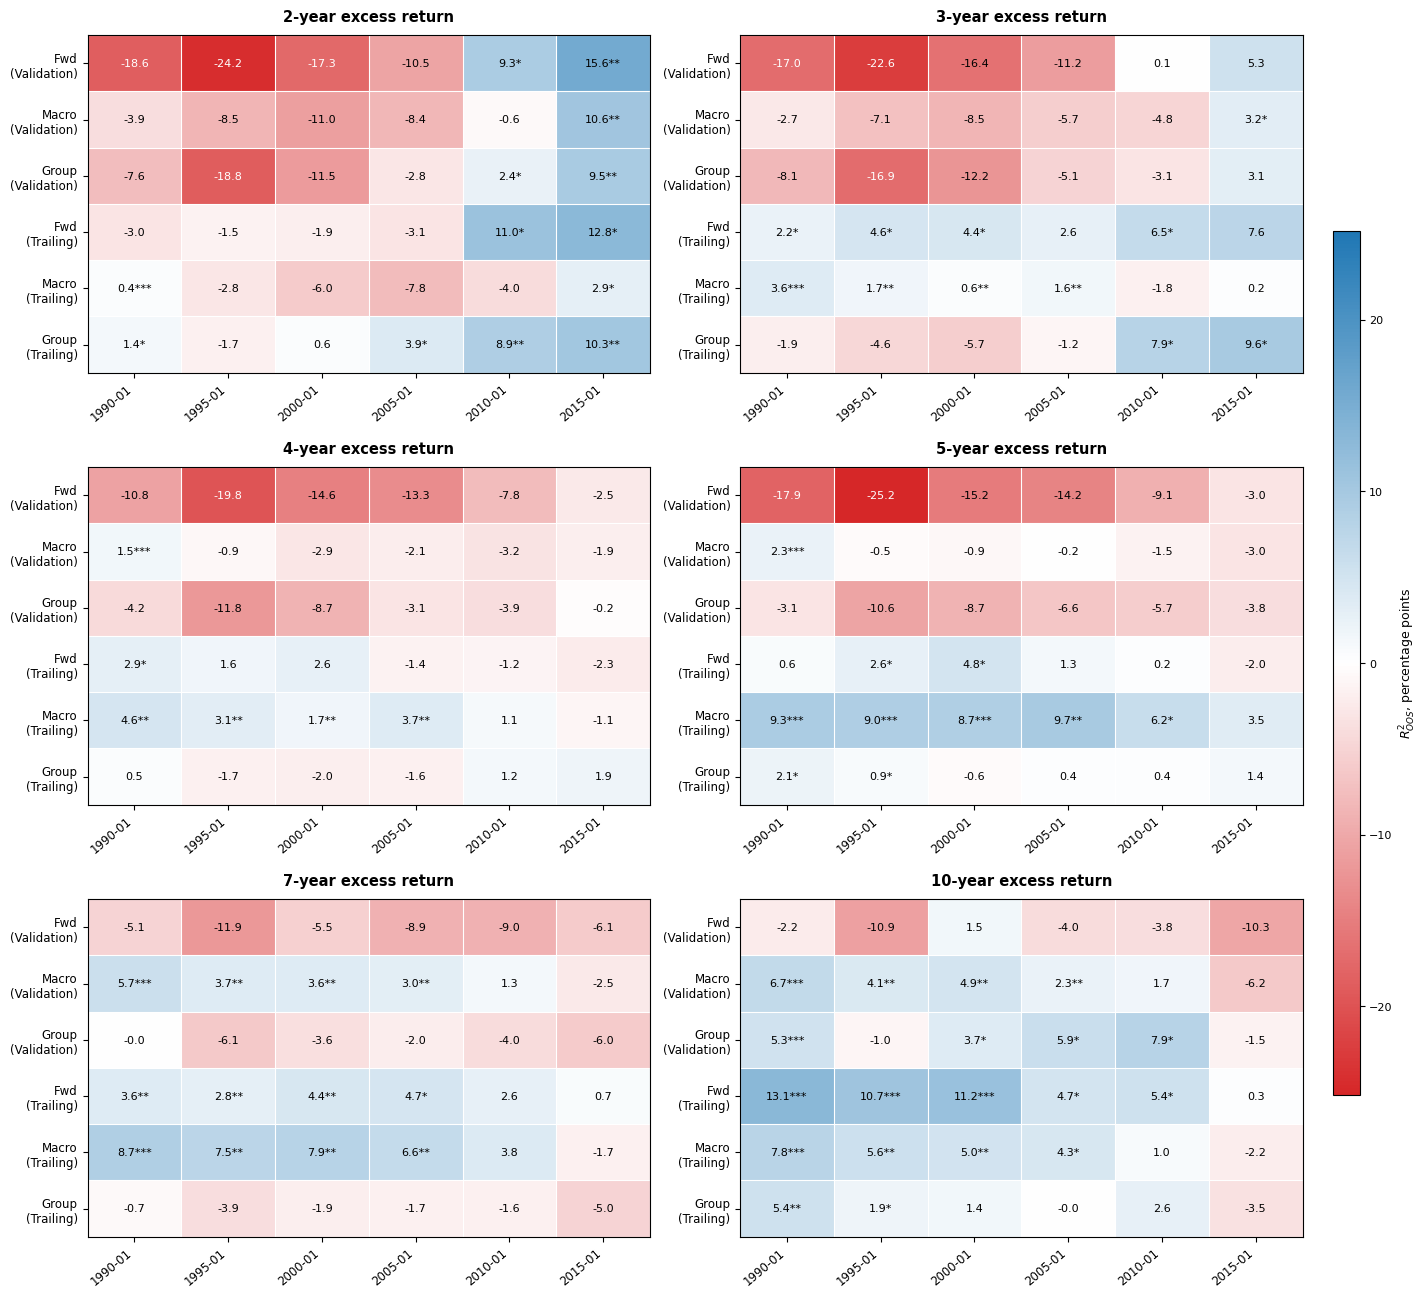


Note: Heatmap entries report R2_OOS in percentage points. Stars are shown only for positive R2_OOS values and are based on bu.RSZ_Signif / CW-RSZ convention: *** p<0.01, ** p<0.05, * p<0.10.


In [32]:
# ============================================================
# OOS START-DATE SENSITIVITY: ANN ENSEMBLES, ALL 6 MATURITIES
# Includes CW/RSZ significance stars in tables and heatmaps
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display

# -----------------------------
# Configuration
# -----------------------------
GAP = 11

EVAL_END_REQUESTED = pd.Timestamp("2025-06-30")
EVAL_END = min(EVAL_END_REQUESTED, pd.Timestamp(dates.max()))

OOS_START_DATES = [
    pd.Timestamp("1990-01-31"),
    pd.Timestamp("1995-01-31"),
    pd.Timestamp("2000-01-31"),
    pd.Timestamp("2005-01-31"),
    pd.Timestamp("2010-01-31"),
    pd.Timestamp("2015-01-31"),
]

SELECTED_MATURITIES = list(target_maturities)

MODEL_FORECASTS = {
    "Fwd\n(Validation)": forward_ens,
    "Macro\n(Validation)": macro_ens,
    "Group\n(Validation)": group_ens,
    "Fwd\n(Trailing)": forward_ens_tr,
    "Macro\n(Trailing)": macro_ens_tr,
    "Group\n(Trailing)": group_ens_tr,
}

MODEL_ORDER = list(MODEL_FORECASTS.keys())

# -----------------------------
# Defensive checks
# -----------------------------
if len(dates) != y_true.shape[0]:
    raise ValueError(f"len(dates)={len(dates)} but y_true.shape[0]={y_true.shape[0]}")

for model_name, forecast in MODEL_FORECASTS.items():
    if forecast.shape != y_true.shape:
        raise ValueError(
            f"{model_name} shape mismatch: forecast.shape={forecast.shape}, "
            f"y_true.shape={y_true.shape}"
        )

# -----------------------------
# Helpers
# -----------------------------
def maturity_label_from_months(mat):
    return f"{int(mat) // 12}-year excess return"

def stars_from_pval(pval):
    if pd.isna(pval):
        return ""
    if pval < 0.01:
        return "***"
    if pval < 0.05:
        return "**"
    if pval < 0.10:
        return "*"
    return ""

def format_r2_pct_with_stars(r2_pct, pval):
    return f"{r2_pct:.1f}{stars_from_pval(pval)}"

def mask_forecast_to_period(forecast, mask):
    f = forecast.copy()
    f[~mask, :] = np.nan
    return f

def score_one_model_one_maturity(y_t, forecast, maturity_idx, mask, gap=11):
    masked_forecast = mask_forecast_to_period(forecast, mask)
    fcst_series = masked_forecast[:, maturity_idx]

    r2 = wu.oos_r2(y_t[:, maturity_idx], fcst_series, gap=gap)

    try:
        pval = bu.RSZ_Signif(y_t[:, maturity_idx], fcst_series, gap=gap)
    except Exception:
        pval = np.nan

    return r2, pval

# -----------------------------
# Build long-form DataFrame
# -----------------------------
rows = []
y_t = y_true.copy()

for start_date in OOS_START_DATES:
    mask = (dates >= start_date) & (dates <= EVAL_END)

    if not np.any(mask):
        raise ValueError(
            f"No evaluation observations for OOS start {start_date.date()} "
            f"and evaluation end {EVAL_END.date()}."
        )

    n_eval_obs = int(mask.sum())

    for maturity_idx, maturity in enumerate(SELECTED_MATURITIES):
        maturity_label = maturity_label_from_months(maturity)

        for model_name, forecast in MODEL_FORECASTS.items():
            r2, pval = score_one_model_one_maturity(
                y_t=y_t,
                forecast=forecast,
                maturity_idx=maturity_idx,
                mask=mask,
                gap=GAP,
            )

            r2_pct = 100.0 * r2

            rows.append({
                "OOS Start": start_date.strftime("%Y-%m"),
                "OOS Start Date": start_date,
                "OOS End": EVAL_END.strftime("%Y-%m"),
                "Maturity": maturity_label,
                "Maturity Months": maturity,
                "Model": model_name,
                "R2_OOS": r2,
                "R2_OOS_pct": r2_pct,
                "pval": pval,
                "stars": stars_from_pval(pval),
                "R2 formatted": format_r2_pct_with_stars(r2_pct, pval),
                "N eval obs": n_eval_obs,
            })

df_oos_start_long = pd.DataFrame(rows)

MATURITY_ORDER = [maturity_label_from_months(m) for m in SELECTED_MATURITIES]

df_oos_start_long["Model"] = pd.Categorical(
    df_oos_start_long["Model"],
    categories=MODEL_ORDER,
    ordered=True,
)

df_oos_start_long["Maturity"] = pd.Categorical(
    df_oos_start_long["Maturity"],
    categories=MATURITY_ORDER,
    ordered=True,
)

df_oos_start_long = df_oos_start_long.sort_values(
    ["Maturity", "OOS Start Date", "Model"]
).reset_index(drop=True)

from matplotlib import colors as mcolors
# -----------------------------
# 3x2 heatmap plot, all maturities
# -----------------------------
def format_r2_pct_with_stars(r2_pct, pval):
    # No significance stars for negative R2_OOS values
    if pd.isna(r2_pct) or r2_pct < 0:
        return f"{r2_pct:.1f}"
    return f"{r2_pct:.1f}{stars_from_pval(pval)}"

# Refresh formatted labels after changing the rule
df_oos_start_long["R2 formatted"] = df_oos_start_long.apply(
    lambda row: format_r2_pct_with_stars(row["R2_OOS_pct"], row["pval"]),
    axis=1,
)

def plot_oos_start_heatmap(ax, heat_values, heat_labels, title, abs_max):
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "oos_start_cmap",
        ["#d62728", "#ffffff", "#1f77b4"],
    )

    norm = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0.0, vmax=abs_max)
    im = ax.imshow(heat_values.values, cmap=cmap, norm=norm, aspect="auto")

    ax.set_xticks(range(len(heat_values.columns)))
    ax.set_yticks(range(len(heat_values.index)))
    ax.set_xticklabels(heat_values.columns, rotation=40, ha="right", fontsize=8.5)
    ax.set_yticklabels(heat_values.index, fontsize=8.5)
    ax.set_title(title, fontsize=10.5, fontweight="bold", pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

    for i in range(heat_values.shape[0]):
        for j in range(heat_values.shape[1]):
            value = heat_values.iloc[i, j]
            label = heat_labels.iloc[i, j]

            if pd.notna(value):
                text_color = "white" if abs(value) > 0.65 * abs_max else "black"
                ax.text(
                    j,
                    i,
                    label,
                    ha="center",
                    va="center",
                    fontsize=8,
                    color=text_color,
                )

    for x in np.arange(-0.5, len(heat_values.index), 1):
        ax.axhline(x, color="white", linewidth=0.8)

    for x in np.arange(-0.5, len(heat_values.columns), 1):
        ax.axvline(x, color="white", linewidth=0.8)

    return im


all_finite_values = (
    df_oos_start_long["R2_OOS_pct"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

if all_finite_values.empty:
    raise ValueError("No finite R2_OOS values available for heatmaps.")

ABS_MAX = max(abs(all_finite_values.min()), abs(all_finite_values.max()), 1e-8)

fig, axes = plt.subplots(3, 2, figsize=(15, 13.5))
axes = axes.ravel()

for ax, maturity_label in zip(axes, MATURITY_ORDER):
    sub = df_oos_start_long[
        df_oos_start_long["Maturity"].astype(str) == maturity_label
    ].copy()

    heat_values = (
        sub
        .pivot(index="Model", columns="OOS Start", values="R2_OOS_pct")
        .reindex(MODEL_ORDER)
    )

    heat_labels = (
        sub
        .pivot(index="Model", columns="OOS Start", values="R2 formatted")
        .reindex(MODEL_ORDER)
    )

    im = plot_oos_start_heatmap(
        ax=ax,
        heat_values=heat_values,
        heat_labels=heat_labels,
        title=maturity_label,
        abs_max=ABS_MAX,
    )

for ax in axes[len(MATURITY_ORDER):]:
    ax.axis("off")

# Leave explicit right margin for colorbar, so it cannot overlap panels
fig.subplots_adjust(
    left=0.075,
    right=0.885,
    bottom=0.075,
    top=0.965,
    wspace=0.16,
    hspace=0.28,
)

cbar_ax = fig.add_axes([0.905, 0.18, 0.018, 0.64])
cbar = fig.colorbar(im, cax=cbar_ax)

cbar.set_label(r"$R^2_{OOS}$, percentage points", fontsize=9)
cbar.ax.tick_params(labelsize=8)

# No suptitle: publication-ready figure body only
plt.show()

print(
    "\nNote: Heatmap entries report R2_OOS in percentage points. "
    "Stars are shown only for positive R2_OOS values and are based on "
    "bu.RSZ_Signif / CW-RSZ convention: "
    "*** p<0.01, ** p<0.05, * p<0.10."
)

# Pairwise DM results

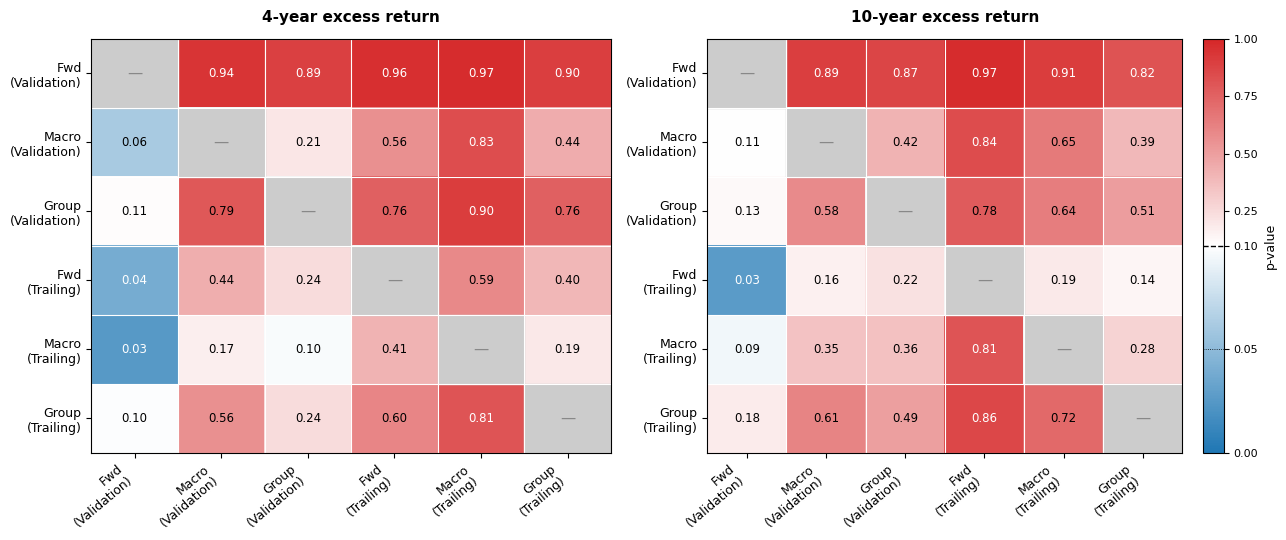

In [33]:
from dieboldmariano import dm_test
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

models = {
    'Fwd\n(Validation)':     forward_ens,
    'Macro\n(Validation)':   macro_ens,
    'Group\n(Validation)':   group_ens,
    'Fwd\n(Trailing)':   forward_ens_tr,
    'Macro\n(Trailing)': macro_ens_tr,
    'Group\n(Trailing)': group_ens_tr,
}
model_names = list(models.keys())
n_models = len(model_names)

n_full = forward_ens.shape[0]
n_true = y_true.shape[0]
offset = n_full - n_true

def compute_dm_matrix(mat_idx):
    y_col = y_true[:, mat_idx]
    pred_cols = {name: arr[offset:, mat_idx] for name, arr in models.items()}

    valid = ~np.isnan(y_col)
    for arr in pred_cols.values():
        valid &= ~np.isnan(arr)

    y = y_col[valid]
    preds = {name: arr[valid] for name, arr in pred_cols.items()}

    pval_mat = np.full((n_models, n_models), np.nan)

    for i, name_i in enumerate(model_names):
        for j, name_j in enumerate(model_names):
            if i == j:
                continue
            _, pval = dm_test(y, preds[name_i], preds[name_j], h=12, one_sided=True)
            pval_mat[i, j] = pval

    return pval_mat

def plot_dm_heatmap(ax, pval_mat, title):
    cmap = mcolors.LinearSegmentedColormap.from_list(
        'dm_cmap', ['#1f77b4', '#ffffff', '#d62728']
    )
    norm = mcolors.TwoSlopeNorm(vmin=0.0, vcenter=0.10, vmax=1.0)

    plot_mat = pval_mat.copy()
    np.fill_diagonal(plot_mat, np.nan)

    im = ax.imshow(plot_mat, cmap=cmap, norm=norm, aspect='auto')

    ax.set_xticks(range(n_models))
    ax.set_yticks(range(n_models))
    ax.set_xticklabels(model_names, rotation=40, ha='right', fontsize=9)
    ax.set_yticklabels(model_names, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=12)
    ax.set_xlabel('')
    ax.set_ylabel('')

    for i in range(n_models):
        for j in range(n_models):
            if i == j:
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                             color='#cccccc', zorder=2))
                ax.text(j, i, '—', ha='center', va='center',
                        fontsize=11, color='#888888', zorder=3)
            else:
                p = pval_mat[i, j]
                if not np.isnan(p):
                    text_color = 'white' if (p < 0.04 or p > 0.80) else 'black'
                    ax.text(j, i, f'{p:.2f}', ha='center', va='center',
                            fontsize=8.5, color=text_color)

    for x in np.arange(-0.5, n_models, 1):
        ax.axhline(x, color='white', linewidth=0.8)
        ax.axvline(x, color='white', linewidth=0.8)

    return im


fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, mat_idx, label in zip(
    axes,
    [2, -1],
    ['4-year excess return', '10-year excess return']
):
    pval_mat = compute_dm_matrix(mat_idx)
    im = plot_dm_heatmap(ax, pval_mat, label)

cbar = fig.colorbar(im, ax=axes[1], orientation='vertical',
                    fraction=0.046, pad=0.04)
cbar.set_label('p-value', fontsize=9)
cbar.set_ticks([0.0, 0.05, 0.10, 0.25, 0.50, 0.75, 1.0])
cbar.ax.tick_params(labelsize=8)
cbar.ax.axhline(0.10, color='black', linewidth=1.0, linestyle='--')
cbar.ax.axhline(0.05, color='black', linewidth=0.6, linestyle=':')

plt.tight_layout()
plt.show()

In [34]:
# plot t, f, and g over time
dates_valid = dates[valid_mask]
plt.figure(figsize=(12, 6))
plt.plot(dates_valid, T, label='True', color='black')
plt.plot(dates_valid, F, label='Forward Trailing Ensemble', color='blue')
plt.plot(dates_valid, G, label='Macro Trailing Ensemble', color='orange')
plt.title('Forecasts vs True Values Over Time')
plt.xlabel('Date')
plt.ylabel('Excess Return')
plt.legend()
plt.show()

# also print r2oos using wu.oos_r2
f_masked = forward_ens_tr[:, -1].copy()
g_masked = macro_ens_tr[:, -1].copy()

r2_f = wu.oos_r2(y_true[:, -1], f_masked, gap=11)
r2_g = wu.oos_r2(y_true[:, -1], g_masked, gap=11)
print(f"R2 OOS for Forward Trailing Ensemble: {r2_f:.4f}")
print(f"R2 OOS for Macro Trailing Ensemble: {r2_g:.4f}")

NameError: name 'valid_mask' is not defined

## Bianchi-style univariate CER (per maturity)

Following Bianchi, Büchner and Tamoni (2021, RFS — *Bond Risk Premiums with Machine Learning*), we evaluate the economic value of each ensemble forecast through a univariate mean-variance investor who chooses, for every maturity \(m\) separately, a bond portfolio weight at every forecast date \(t\).

**Strict real-time, non-overlapping annual setting.** \(y_t^{(m)}\) is the realized 12-month-ahead excess return on the \(m\)-month bond. At time \(t\), only realizations with \(\tau + 12 \le t\) (equivalently \(\tau \le t-12\)) are known. We use the project-wide convention `gap = 11`.

**Forecasts (already produced — no retraining).** For each maturity \(m\):

- model forecast \(\hat r^{(m,s)}_{t+12|t}\): the top-10 ensemble from the orchestrator runs (both val-loss and trailing-OOS selection rules are reported);
- benchmark \(\hat r^{(m,\text{HM})}_{t+12|t}\): the strict real-time expanding historical mean,
$$\hat r^{(m,\text{HM})}_{t+12|t} = \frac{1}{|\{\tau: \tau \le t-12\}|}\sum_{\tau \le t-12} y_\tau^{(m)}.$$

**Conditional variance (BBT EWMA of squared past forecast errors).** Following Thornton and Valente (2012) as in BBT (2021), separately for the model and the benchmark,
$$\hat\sigma^{2(m,s)}_{t} = \sum_{\tau \le t-12} \omega_\tau \,\big(y_\tau^{(m)} - \hat r^{(m,s)}_{\tau+12|\tau}\big)^2,$$
with EWMA weights (decay \(\alpha = 0.05\)) over strictly-past forecast errors, requiring at least `min_history = 12` valid past errors (one annual cycle for \(h=12\)) before any portfolio decision is made.

**Portfolio weight.** With risk aversion \(\gamma = 5\),
$$w^{(m,s)}_{t} = \operatorname{clip}\!\left(\frac{\hat r^{(m,s)}_{t+12|t}}{\gamma\,\hat\sigma^{2(m,s)}_{t}}, w_{\text{lo}}, w_{\text{hi}}\right),$$
with bounds \(w \in [-1, 2]\) as in BBT (2021).

**Realized MV utility on the next-12M return.**
$$u^{(m,s)}_{t+12} = w^{(m,s)}_{t}\, y_t^{(m)} - \tfrac{\gamma}{2}\big(w^{(m,s)}_{t}\big)^2 \hat\sigma^{2(m,s)}_{t}.$$

**CER gain in percent.** With annualization factor \(A=1\) because each \(y_t^{(m)}\) is already a 12-month return,
$$\text{CER}^{(m,s)} = 100 \cdot A \cdot \big(\bar u^{(m,s)} - \bar u^{(m,\text{HM})}\big).$$

**Significance (BBT Table 5).** One-sided Diebold–Mariano test with the Harvey–Leybourne–Newbold (1997) correction on utility differences \(u^{\text{model}}_t - u^{\text{HM}}_t\), using \(h=12\) for annual holding-period returns. Stars: \(*\) \(p<0.10\), \(**\) \(p<0.05\), \(***\) \(p<0.01\).

In [41]:
# Bianchi-style univariate mean-variance CER per maturity.
# Strict real-time: at time t, only y_true[tau] with tau <= t - 12 are observable.

GAMMA_CER = 5.0
A_ANNUAL = 1.0            # 12-month returns -> A = 1 (no further annualization)
CER_GAP = 11              # project-wide non-overlap convention; last observed tau is t - 12
CER_MIN_HISTORY = 12      # one annual cycle of past errors (h=12); DO NOT change without re-benchmarking CER levels
BBT_EWMA_ALPHA = 0.05     # BBT (2021) variance estimator: EWMA of squared forecast errors, alpha=0.05 (Thornton-Valente 2012)
WEIGHT_BOUNDS_MAIN = (-1.0, 2.0)

# --- locked CER specification (CER levels depend ONLY on this block, not on dm_hln_pvalue) ---
CER_SPEC = {
    "variance": f"BBT EWMA alpha={BBT_EWMA_ALPHA}",
    "min_history": CER_MIN_HISTORY,
    "gap": CER_GAP,
    "gamma": GAMMA_CER,
    "eval_from": "1990-01-31",
}
print("CER spec (frozen):", CER_SPEC)
print("Note: p-value / star changes do NOT affect CER numbers; only variance estimator, min_history, weights, and eval window do.")

eval_mask = dates >= pd.Timestamp("1990-01-31")

cer_forecasts = {
    "Forward-only (Val Loss)":   forward_ens,
    "Macro-forward (Val Loss)":  macro_ens,
    "Group-ensemble (Val Loss)": group_ens,
    "Forward-only (Trailing)":   forward_ens_tr,
    "Macro-forward (Trailing)":  macro_ens_tr,
    "Group-ensemble (Trailing)": group_ens_tr,
}

y_panel = np.asarray(y_true, dtype=float)
T_cer, n_mat_cer = y_panel.shape


def realtime_hist_mean(y_arr, gap=CER_GAP):
    """Expanding historical-mean benchmark using only returns realized by time t."""
    T = y_arr.shape[0]
    hm = np.full_like(y_arr, np.nan, dtype=float)
    for t in range(1, T):
        end = t - gap
        if end >= 1:
            past = y_arr[:end]
            if np.any(~np.isnan(past), axis=0).all():
                hm[t] = np.nanmean(past, axis=0)
    return hm


def forecast_error_variance(errors, gap=CER_GAP, min_history=CER_MIN_HISTORY, alpha=BBT_EWMA_ALPHA):
    """BBT (2021) EWMA of squared past forecast errors (alpha=0.05; Thornton-Valente 2012).

    At time t, use strictly-past errors {e_tau : tau <= t - gap}.
    """
    T = errors.shape[0]
    var = np.full(T, np.nan, dtype=float)
    for t in range(T):
        end = t - gap
        if end < 1:
            continue
        past = errors[:end]
        past = past[~np.isnan(past)]
        n = past.size
        if n < min_history:
            continue
        # Newest error gets the highest weight: weight at lag l (0 = newest) is alpha * (1-alpha)^l.
        weights = alpha * (1.0 - alpha) ** np.arange(n - 1, -1, -1)
        weights = weights / weights.sum()
        var[t] = float(np.sum(weights * past ** 2))
    return var


def mv_utility(weights, realized, variance, gamma=GAMMA_CER):
    return weights * realized - 0.5 * gamma * (weights ** 2) * variance


from scipy.stats import t as _student_t

def dm_hln_pvalue(d, h=12):
    """One-sided DM--HLN p-value (BBT 2021 Table 5; HLN 1997 Eq. 9).

    H0: E[d_t] <= 0 vs H1: E[d_t] > 0 on utility differences d_t = u_model - u_bench.
    Uses BBT's bundled variance for the sample mean (autocovariances through lag h-1
    plus the HLN finite-sample factor), not a separate Newey-West step.
    """
    d = np.asarray(d, dtype=float)
    d = d[~np.isnan(d)]
    n = d.size
    if n < max(5, h + 1):
        return np.nan
    d_bar = float(np.mean(d))
    gamma0 = float(np.mean((d - d_bar) ** 2))
    lr_var = gamma0
    for k in range(1, h):
        cov_k = float(np.mean((d[k:] - d_bar) * (d[:-k] - d_bar)))
        lr_var += 2.0 * (n - k) / n * cov_k
    hln_factor = (n + 1.0 - 2.0 * h + h * (h - 1.0) / n) / (n ** 2)
    if hln_factor <= 0:
        return np.nan
    var_d_bar = hln_factor * lr_var
    if not np.isfinite(var_d_bar) or var_d_bar <= 0:
        return np.nan
    dm_hln = d_bar / np.sqrt(var_d_bar)
    return float(1.0 - _student_t.cdf(dm_hln, df=n - 1))


def stars_for_pvalue(p):
    if not np.isfinite(p):
        return ""
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""


hm_bench = realtime_hist_mean(y_panel, gap=CER_GAP)


def evaluate_bianchi_cer(forecast_panel, weight_bounds, eval_mask=None):
    """Per-maturity CER results for one ensemble vs. the historical-mean benchmark."""
    w_lo, w_hi = weight_bounds
    rows = []
    diagnostics = {}
    for m, mat in enumerate(target_maturities):
        f_model = forecast_panel[:, m]
        f_bench = hm_bench[:, m]
        rx = y_panel[:, m]

        err_model = rx - f_model
        err_bench = rx - f_bench

        var_model = forecast_error_variance(err_model)
        var_bench = forecast_error_variance(err_bench)

        with np.errstate(divide="ignore", invalid="ignore"):
            w_model = f_model / (GAMMA_CER * var_model)
            w_bench = f_bench / (GAMMA_CER * var_bench)
        w_model = np.clip(w_model, w_lo, w_hi)
        w_bench = np.clip(w_bench, w_lo, w_hi)

        u_model = mv_utility(w_model, rx, var_model)
        u_bench = mv_utility(w_bench, rx, var_bench)

        # Strictly real-time evaluation: only count dates where all inputs are observable
        valid = (
            ~np.isnan(f_model)
            & ~np.isnan(f_bench)
            & ~np.isnan(var_model)
            & ~np.isnan(var_bench)
            & ~np.isnan(rx)
        )
        
        # Apply the explicit evaluation dates bounds if passed
        if eval_mask is not None:
            valid = valid & eval_mask

        if not valid.any():
            rows.append({
                "Maturity": mat,
                "obs": 0,
                "CER_pct": np.nan,
                "DM_HLN_pval": np.nan,
                "avg_w_model": np.nan,
                "avg_w_bench": np.nan,
            })
            continue

        u_m = float(np.mean(u_model[valid]))
        u_b = float(np.mean(u_bench[valid]))
        d_series = (u_model - u_bench)[valid]
        pval = dm_hln_pvalue(d_series, h=12)
        rows.append({
            "Maturity": mat,
            "obs": int(valid.sum()),
            "CER_pct": 100.0 * A_ANNUAL * (u_m - u_b),
            "DM_HLN_pval": pval,
            "avg_w_model": float(np.mean(w_model[valid])),
            "avg_w_bench": float(np.mean(w_bench[valid])),
        })

        diagnostics[mat] = {
            "weights_model": w_model,
            "weights_bench": w_bench,
            "utility_model": u_model,
            "utility_bench": u_bench,
            "valid_mask": valid,
        }
    return pd.DataFrame(rows), diagnostics


def _format_bbt_cell(cer, pval):
    if not np.isfinite(cer):
        return "\u2014"
    return f"{cer:+.3f}{stars_for_pvalue(pval)}"


def _format_bbt_pval(pval):
    if not np.isfinite(pval):
        return "\u2014"
    return f"({pval:.3f})"


def compute_pairwise_delta(diag_a, diag_b, maturities):
    """Per-maturity Δ CER between two ensembles plus DM-HLN p-value on (u_A - u_B)."""
    rows = []
    for mat in maturities:
        if mat not in diag_a or mat not in diag_b:
            rows.append({"Maturity": mat, "delta_CER_pct": np.nan, "DM_HLN_pval": np.nan})
            continue
        u_a = diag_a[mat]["utility_model"]
        u_b = diag_b[mat]["utility_model"]
        valid = diag_a[mat]["valid_mask"] & diag_b[mat]["valid_mask"]
        if not valid.any():
            rows.append({"Maturity": mat, "delta_CER_pct": np.nan, "DM_HLN_pval": np.nan})
            continue
        d = (u_a - u_b)[valid]
        delta_mean = float(np.mean(d))
        pval = dm_hln_pvalue(d, h=12)
        rows.append({
            "Maturity": mat,
            "delta_CER_pct": 100.0 * A_ANNUAL * delta_mean,
            "DM_HLN_pval": pval,
        })
    return pd.DataFrame(rows).set_index("Maturity")


def build_bbt_style_table(full, cer_forecasts, target_maturities, delta_rows=None):
    """BBT Table-5 style: ensemble blocks (value + p-value), then optional Δ blocks."""
    row_labels = []
    rows_data = []
    for name in cer_forecasts.keys():
        sub = full.loc[name]
        cer_row = {mat: _format_bbt_cell(sub.loc[mat, "CER_pct"], sub.loc[mat, "DM_HLN_pval"]) for mat in target_maturities}
        pval_row = {mat: _format_bbt_pval(sub.loc[mat, "DM_HLN_pval"]) for mat in target_maturities}
        rows_data.append(cer_row)
        row_labels.append(name)
        rows_data.append(pval_row)
        row_labels.append("  p-value")
    if delta_rows:
        for delta_label, delta_df in delta_rows.items():
            cer_row = {mat: _format_bbt_cell(delta_df.loc[mat, "delta_CER_pct"], delta_df.loc[mat, "DM_HLN_pval"]) for mat in target_maturities}
            pval_row = {mat: _format_bbt_pval(delta_df.loc[mat, "DM_HLN_pval"]) for mat in target_maturities}
            rows_data.append(cer_row)
            row_labels.append(delta_label)
            rows_data.append(pval_row)
            row_labels.append("  p-value")
    out = pd.DataFrame(rows_data, index=row_labels)
    out.columns = [f"{m}M" for m in target_maturities]
    out.columns.name = "Maturity"
    return out


def collect_cer_table(weight_bounds, label, eval_mask=None):
    long_rows = []
    diag_store = {}
    for name, fc in cer_forecasts.items():
        df_per_mat, diag = evaluate_bianchi_cer(fc, weight_bounds, eval_mask=eval_mask)
        diag_store[name] = diag
        long_rows.append(df_per_mat.assign(Ensemble=name))
    full = pd.concat(long_rows, ignore_index=True).set_index(["Ensemble", "Maturity"])

    all_masks = [d["valid_mask"] for diag in diag_store.values() for d in diag.values() if d["valid_mask"].any()]
    if all_masks:
        common = np.logical_and.reduce(all_masks)
        valid_dates = dates[common]
        window = f"{valid_dates[0].strftime('%Y-%m')} to {valid_dates[-1].strftime('%Y-%m')} ({int(common.sum())} months)"
    else:
        window = "no valid observations"

    var_label = f"BBT EWMA of squared forecast errors (alpha={BBT_EWMA_ALPHA})"

    # Pairwise deltas, one set per selection rule (matches BBT's Δ Fwd+Macro vs Fwd column)
    delta_rows = {}
    for selection_label, suffix in [("Val Loss", "(Val Loss)"), ("Trailing", "(Trailing)")]:
        fwd_key = f"Forward-only {suffix}"
        mac_key = f"Macro-forward {suffix}"
        grp_key = f"Group-ensemble {suffix}"
        if fwd_key in diag_store and mac_key in diag_store:
            delta_rows[f"\u0394 Macro \u2212 Fwd ({selection_label})"] = compute_pairwise_delta(
                diag_store[mac_key], diag_store[fwd_key], target_maturities
            )
        if fwd_key in diag_store and grp_key in diag_store:
            delta_rows[f"\u0394 Group \u2212 Fwd ({selection_label})"] = compute_pairwise_delta(
                diag_store[grp_key], diag_store[fwd_key], target_maturities
            )

    bbt_table = build_bbt_style_table(full, cer_forecasts, target_maturities, delta_rows=delta_rows or None)
    cer_pivot = (
        full.reset_index()
        .pivot(index="Maturity", columns="Ensemble", values="CER_pct")
        .reindex(target_maturities)
        .reindex(columns=list(cer_forecasts.keys()))
    )
    print(f"{label} | weights in [{weight_bounds[0]}, {weight_bounds[1]}], gamma={GAMMA_CER}, {var_label}")
    print(f"OOS evaluation window: {window}")
    display(bbt_table)
    print("Raw CER (% per year, no stars):")
    display(cer_pivot.round(3))
    print("Significance: *** p<0.01, ** p<0.05, * p<0.10 (one-sided DM--HLN on u_model - u_HM, BBT 2021)")
    return full, bbt_table, diag_store


cer_main_df, cer_main_table, _ = collect_cer_table(
    WEIGHT_BOUNDS_MAIN,
    "Univariate CER (% per year)",
    eval_mask=eval_mask,
)

CER spec (frozen): {'variance': 'BBT EWMA alpha=0.05', 'min_history': 12, 'gap': 11, 'gamma': 5.0, 'eval_from': '1990-01-31'}
Note: p-value / star changes do NOT affect CER numbers; only variance estimator, min_history, weights, and eval window do.
Univariate CER (% per year) | weights in [-1.0, 2.0], gamma=5.0, BBT EWMA of squared forecast errors (alpha=0.05)
OOS evaluation window: 1991-12 to 2024-06 (391 months)


Maturity,24M,36M,48M,60M,84M,120M
Forward-only (Val Loss),-0.299,-0.670,-0.439,-0.989,-0.029,+0.299
p-value,(0.987),(0.971),(0.861),(0.935),(0.516),(0.401)
Macro-forward (Val Loss),-0.062,-0.282,-0.075,+0.198,+0.512,+0.747
p-value,(0.634),(0.761),(0.566),(0.332),(0.212),(0.211)
Group-ensemble (Val Loss),-0.344,-0.718,-0.614,-0.479,-0.101,+0.204
p-value,(0.915),(0.922),(0.850),(0.735),(0.539),(0.439)
Forward-only (Trailing),+0.050,+0.145,+0.279,+0.309,+0.292,+1.551*
p-value,(0.232),(0.214),(0.182),(0.275),(0.309),(0.096)
Macro-forward (Trailing),-0.020,-0.106,-0.056,+0.576*,+0.739*,+0.799
p-value,(0.556),(0.627),(0.560),(0.079),(0.081),(0.205)


Raw CER (% per year, no stars):


Ensemble,Forward-only (Val Loss),Macro-forward (Val Loss),Group-ensemble (Val Loss),Forward-only (Trailing),Macro-forward (Trailing),Group-ensemble (Trailing)
Maturity,,,,,,
24,-0.299,-0.062,-0.344,0.050,-0.020,-0.106
36,-0.670,-0.282,-0.718,0.145,-0.106,-0.764
48,-0.439,-0.075,-0.614,0.279,-0.056,-0.262
60,-0.989,0.198,-0.479,0.309,0.576,-0.033
84,-0.029,0.512,-0.101,0.292,0.739,-0.392
120,0.299,0.747,0.204,1.551,0.799,0.027


Significance: *** p<0.01, ** p<0.05, * p<0.10 (one-sided DM--HLN on u_model - u_HM, BBT 2021)


## CSSED Plots

Next, we generate the Cumulative Sum of Squared Error Differences (CSSED) plots relative to the Historical Mean benchmark. We add a secondary line starting in 2019-01-31 to highlight the recent Out-of-Sample performance.

A positive slope implies the model is outperforming the benchmark, and a negative slope implies underperformance.

Plotting for Maturities: 24 and 120 months


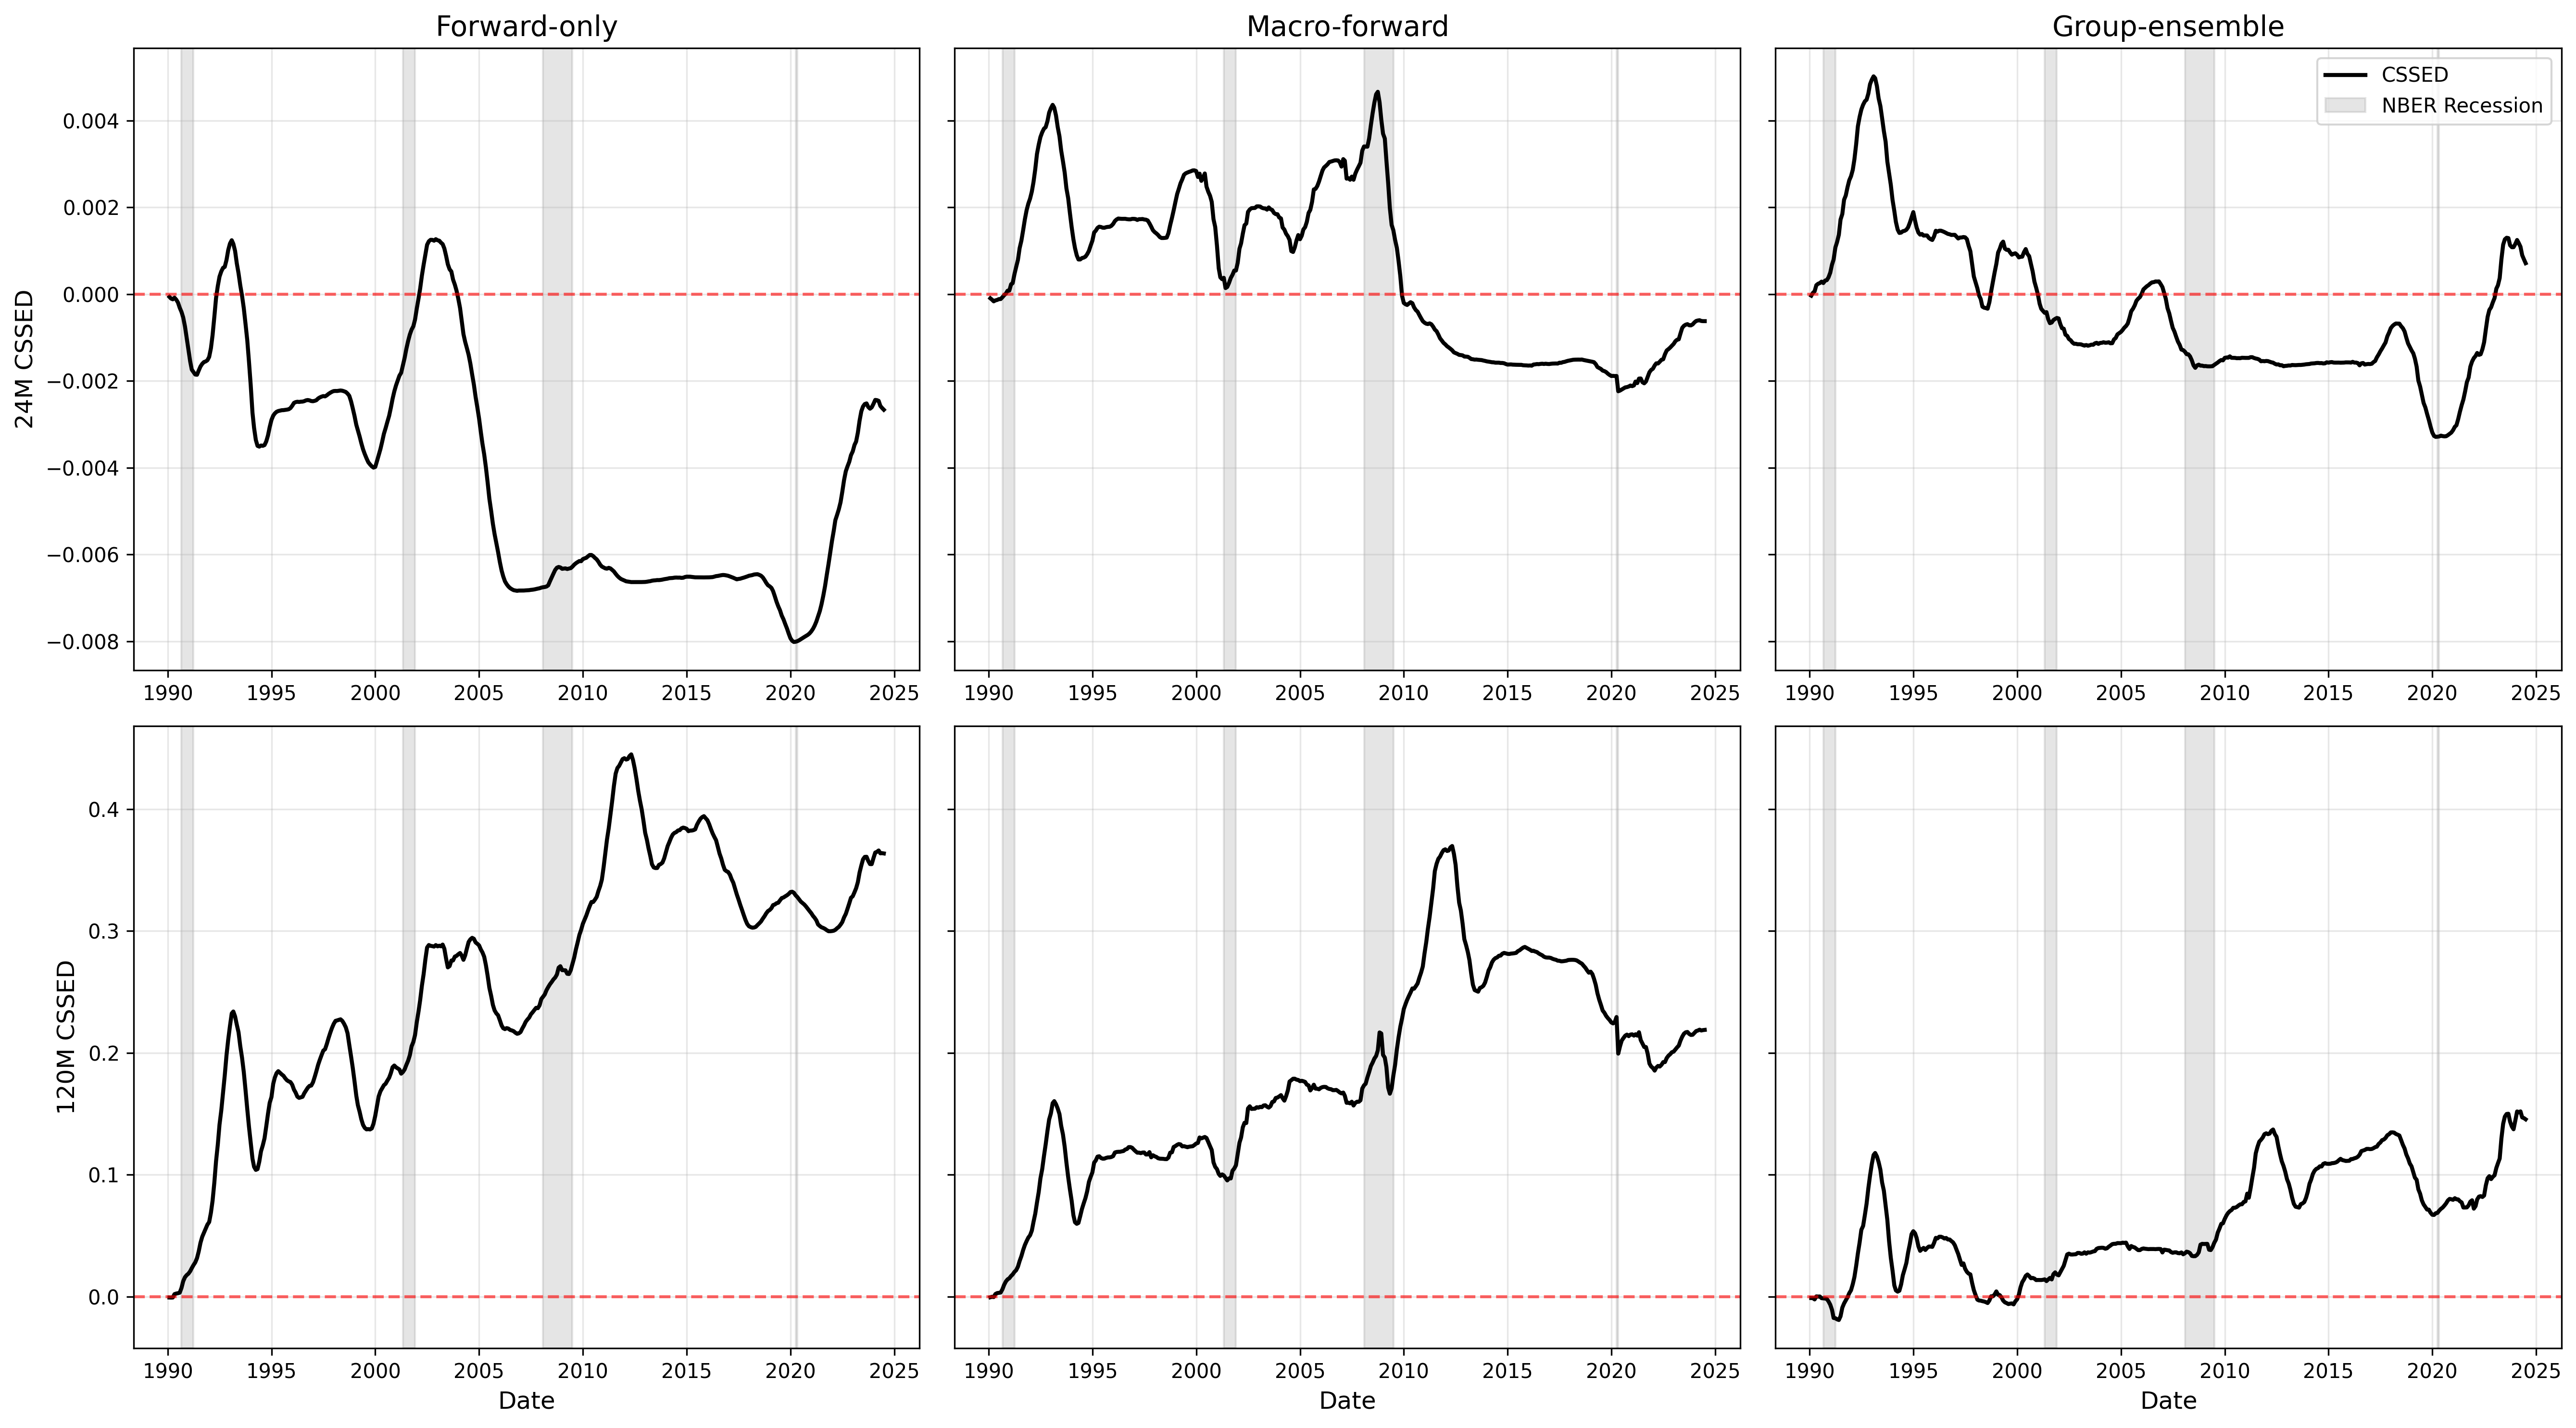

In [ ]:
# Set the secondary start for the CSSED plot
secondary_start = pd.Timestamp('2019-01-31')
gap = 11

# Let's plot for 24-month and 120-month maturities
mat_indices = [0, -1] # 24M is index 0, 120M is index -1 in target_maturities
print(f"Plotting for Maturities: {target_maturities[mat_indices[0]]} and {target_maturities[mat_indices[1]]} months")

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.dates as mdates

# Use sharey='row' so the y-axis limits automatically encompass all data in a row
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey='row', dpi=300)
names = ['Forward-only', 'Macro-forward', 'Group-ensemble']

ensembles = [forward_ens_tr, macro_ens_tr, group_ens_tr] # trailing OOS ensembles 
# ensembles = [forward_ens, macro_ens, group_ens] # validation loss ensembles 


for row, mat_idx in enumerate(mat_indices):
    for col, (name, ens) in enumerate(zip(names, ensembles)):
        ax = axes[row, col]
        
        # Align data and filter for OOS period
        df = pd.DataFrame({
            'realized': y_true[:, mat_idx],
            'forecast': ens[:, mat_idx]
        }, index=dates)
        
        oos_df = df.loc[OOS_start_idx:].copy()
        
        # Generate Historical Mean Benchmark (Expanding Window)
        full_series = pd.Series(y_true[:, mat_idx], index=dates)
        oos_df['hist_mean_bench'] = [full_series.loc[:d].iloc[:-(gap + 1)].mean() for d in oos_df.index]
        
        oos_df['error_model'] = (oos_df['realized'] - oos_df['forecast'])**2
        oos_df['error_bench'] = (oos_df['realized'] - oos_df['hist_mean_bench'])**2
        oos_df['cssed'] = (oos_df['error_bench'] - oos_df['error_model']).cumsum()
        
        # BBT-style CSSED normalization by the variance of the realized series in the pre-OOS period (using ddof=1 for sample variance)
        # sigma2_y = full_series.loc[:OOS_start_idx].var(ddof=1)

        # oos_df['error_model'] = (oos_df['realized'] - oos_df['forecast'])**2
        # oos_df['error_bench'] = (oos_df['realized'] - oos_df['hist_mean_bench'])**2

        # oos_df['cssed'] = (
        #     (oos_df['error_bench'] - oos_df['error_model']) / sigma2_y
        # ).cumsum()
        
        ax.plot(oos_df.index, oos_df['cssed'], color='black', linewidth=2, label='CSSED')
        ax.axhline(0, color='red', linestyle='--', alpha=0.6)
        
        # Add recession shading
        oos_rec = recession_indicators.reindex(oos_df.index, method='ffill').fillna(0)
        ax.fill_between(oos_df.index, 0, 1, where=(oos_rec['USREC'] == 1), 
                        color='gray', alpha=0.2, transform=ax.get_xaxis_transform(), label='NBER Recession')
        
        if row == 0:
            ax.set_title(name, fontsize=14)
        if row == len(mat_indices) - 1:
            ax.set_xlabel('Date', fontsize=12)
        ax.grid(alpha=0.3)
        
        # if secondary_start and secondary_start in oos_df.index:
        #     val_at_secondary = oos_df.loc[secondary_start, 'cssed']
        #     ax2 = ax.twinx()
            
        #     # Use matplotlib's autoscale to make sure the main axis is sized properly first
        #     ax.autoscale(enable=True, axis='y')
        #     y1_min, y1_max = ax.get_ylim()
            
        #     ax2.set_ylim(y1_min - val_at_secondary, y1_max - val_at_secondary)
        #     ax2.axhline(0, color='gray', linestyle=':', alpha=0.5)
        #     ax.axvline(secondary_start, color='blue', linestyle='--', alpha=0.3)
            
        #     # Only add the secondary y-label on the rightmost plot
        #     if col == 2:
        #         ax2.set_ylabel(f'CSSED (Zero at {secondary_start.year})', fontsize=12)
        #     else:
        #         ax2.set_yticklabels([]) # Hide tick labels so it doesn't clutter the middle of the grid
                
        # Add primary y-label only on the leftmost plot
        if col == 0:
            ax.set_ylabel(f'{target_maturities[mat_idx]}M CSSED', fontsize=12)

        # Set x-axis ticks to multiples of 5 years (1990, 1995, 2000, ...)
        ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Custom legend on the last ax
custom_lines = [
    Line2D([0], [0], color='black', lw=2),
    mpatches.Patch(color='gray', alpha=0.2)
]
axes[0, -1].legend(custom_lines, ['CSSED', 'NBER Recession'], loc='best', prop={'size': 10})

plt.tight_layout()
plt.show()

## Seed Stability and Disperion 

For a high-quality finance publication, demonstrating the robustness of machine learning models to the random initialization weight (the "seed") is paramount. 
We propose two foundational figures for the paper:

1. **Ensemble Value Add (R2 Distribution Boxplot):** Demonstrates whether the top-10 val loss ensemble merely captures the average performance of the model class, or actively selects superior weights preventing massive downside risk.
2. **Forecast Uncertainty (Spaghetti Plot):** Demonstrates how widely the underlying model predictions diverge during high volatility periods (like the 2020 drop and subsequent recovery).

First, we load the raw individual seed forecasts for all 100 models.

In [ ]:
# Load the full (100 seeds) forecast arrays
macro_forecasts_all = np.load(os.path.join(macro_dir, 'forecasts_arr.npy'))
group_forecasts_all = np.load(os.path.join(group_dir, 'forecasts_arr.npy'))

print(f"Shape of macro_forecasts_all: {macro_forecasts_all.shape} (Time, Seeds, Maturities)")

Shape of macro_forecasts_all: (635, 100, 6) (Time, Seeds, Maturities)


## Seed instability visualization

Here we generate the finalized 1x3 grid plots comparing the Forward-only, Macro-Forward, and Group-Ensemble models side-by-side for the three seed instability arguments.

In [ ]:
# Prepare data dictionaries for easy 1x3 iteration
model_dirs = {
    'Forward-only': forward_dir,
    'Macro-forward': macro_dir,
    'Group-ensemble': group_dir
}

forecasts_dict = {}

# --- Trailing OOS ensembles ---
# ens_dict = {
#     'Forward-only': forward_ens_tr,
#     'Macro-forward': macro_ens_tr,
#     'Group-ensemble': group_ens_tr
# }
# topk_dict = {
#     'Forward-only': forward_topk_tr,
#     'Macro-forward': macro_topk_tr,
#     'Group-ensemble': group_topk_tr
# }

# # --- Val Loss ensembles ---
ens_dict = {
    'Forward-only': forward_ens,
    'Macro-forward': macro_ens,
    'Group-ensemble': group_ens
}
topk_dict = {
    'Forward-only': forward_topk,
    'Macro-forward': macro_topk,
    'Group-ensemble': group_topk
}


for name, mdir in model_dirs.items():
    forecasts_dict[name] = np.load(os.path.join(mdir, 'forecasts_arr.npy'))

# Reconstruct loss_dates and start_plot_idx for the downstream plots
n_time = forecasts_dict['Group-ensemble'].shape[0]
loss_dates = dates[-n_time:]
start_plot_idx = np.where(loss_dates >= pd.Timestamp('1990-01-31'))[0][0]

/tmp/ipykernel_3015459/398111406.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(target_maturities)
/tmp/ipykernel_3015459/398111406.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(target_maturities)
/tmp/ipykernel_3015459/398111406.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(target_maturities)


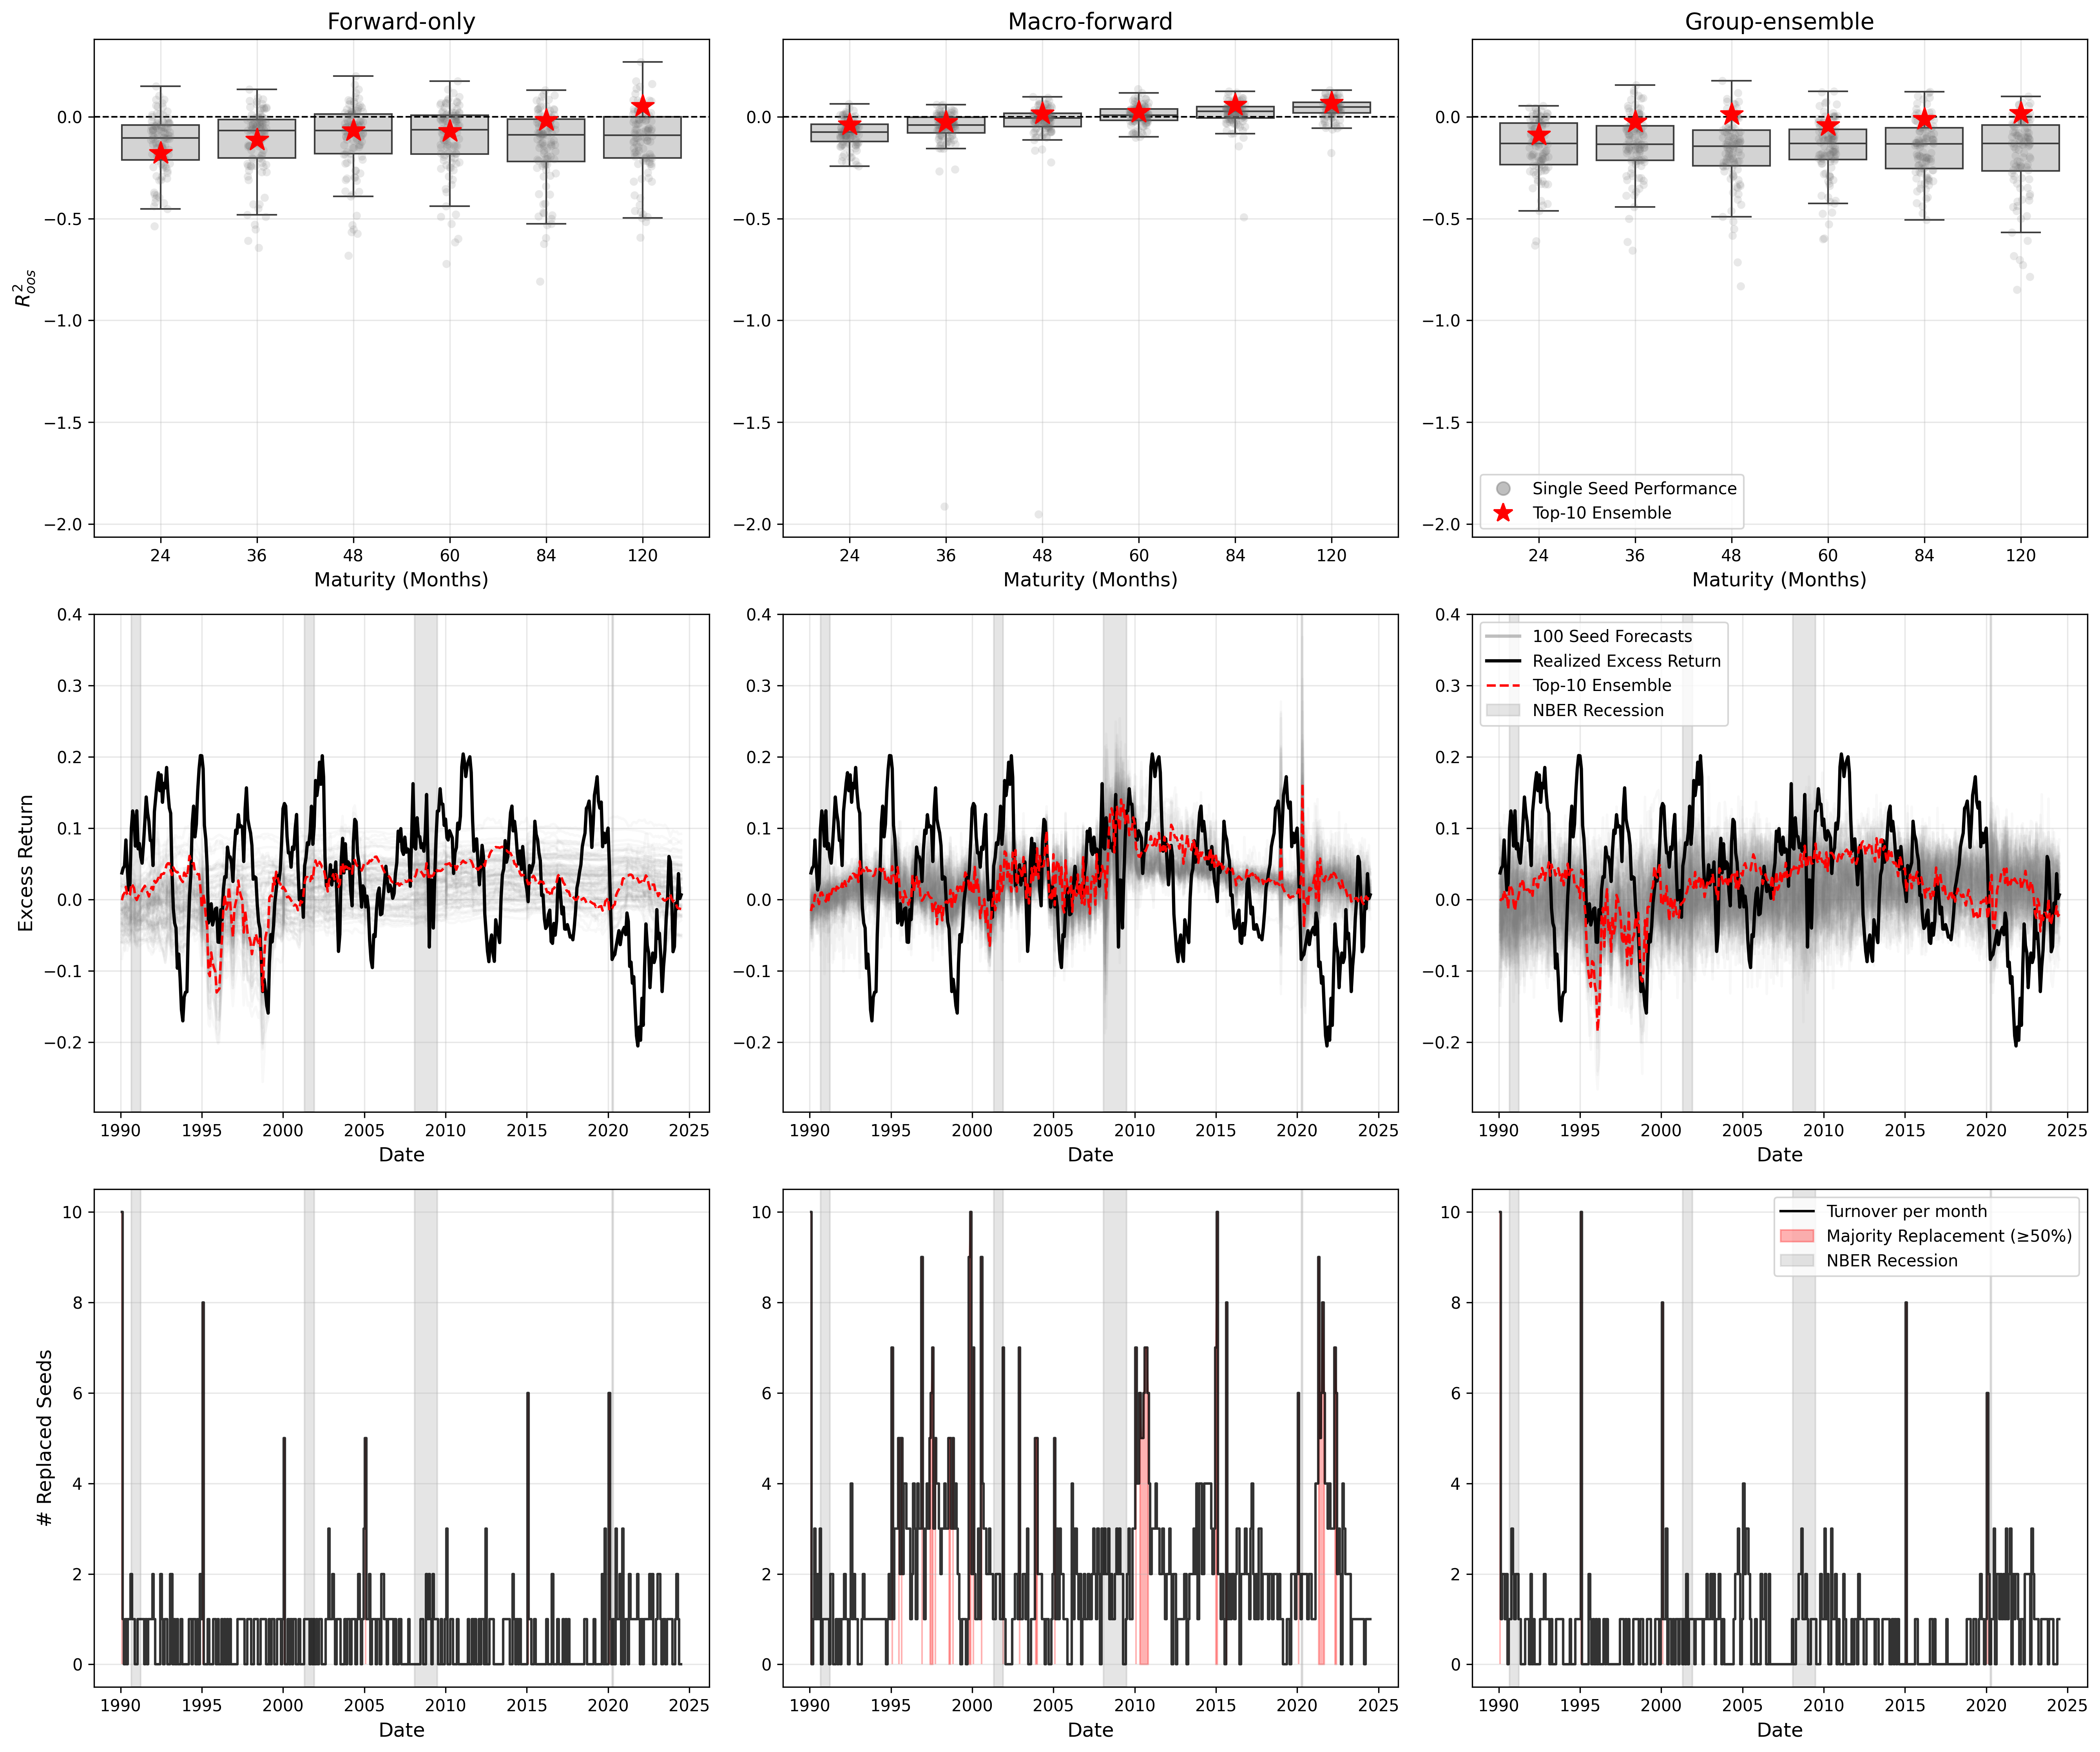

In [ ]:
# Combined 3x3 Seed Instability Plot
def compute_all_seeds_r2(y_true_full, forecasts_all, gap=11):
    """Calculate Full-Sample OOS R2 for individual seeds across all maturities."""
    n_seeds = forecasts_all.shape[1]
    n_maturities = forecasts_all.shape[2]
    
    all_r2 = np.zeros((n_seeds, n_maturities))
    for s in range(n_seeds):
        for m in range(n_maturities):
            r2 = wu.oos_r2(y_true_full[:, m], forecasts_all[:, s, m], benchmark='hist_mean', gap=gap)
            all_r2[s, m] = r2
    return all_r2

mat_idx = -1 # 120M
time_subset = loss_dates[start_plot_idx:]

fig, axes = plt.subplots(3, 3, figsize=(18, 15), dpi=300)

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.dates as mdates

model_names = list(forecasts_dict.keys())

for col, name in enumerate(model_names):
    f_all = forecasts_dict[name]
    t_idx = topk_dict[name]
    
    # --- Row 1: Ensemble Value Add (Boxplots) ---
    ax1 = axes[0, col]
    seeds_r2 = compute_all_seeds_r2(y_true, f_all, gap=11)
    sns.boxplot(data=seeds_r2, ax=ax1, color='lightgray', showfliers=False)
    sns.stripplot(data=seeds_r2, ax=ax1, alpha=0.15, jitter=True, color='dimgray')
    
    # Overlay ensemble performance
    ens_r2s = [wu.oos_r2(y_true[:, m], ens_dict[name][:, m], benchmark='hist_mean', gap=11) for m in range(len(target_maturities))]
    ax1.scatter(range(len(target_maturities)), ens_r2s, color='red', marker='*', s=200, zorder=5)
    
    ax1.set_title(name, fontsize=14)
    if col == 0:
        ax1.set_ylabel('$R^2_{oos}$', fontsize=12)
    else:
        ax1.sharey(axes[0, 0])
        
    ax1.set_xticklabels(target_maturities)
    ax1.set_xlabel('Maturity (Months)', fontsize=12)
    ax1.axhline(0, color='black', linestyle='--', linewidth=1)
    ax1.grid(alpha=0.3)
    
    # --- Row 2: Forecast Dispersion (Spaghetti Plot) ---
    ax2 = axes[1, col]
    full_date_idx = np.where(dates >= pd.Timestamp('1990-01-31'))[0][0]
    seeds_subset = f_all[full_date_idx:, :, mat_idx]
    
    ax2.plot(time_subset, seeds_subset, color='gray', alpha=0.05) 
    ax2.plot(time_subset, y_true[full_date_idx:, mat_idx], color='black', linewidth=2)
    ax2.plot(time_subset, ens_dict[name][full_date_idx:, mat_idx], color='red', linewidth=1.5, linestyle='--')
    
    rec_subset = recession_indicators.reindex(time_subset, method='ffill').fillna(0)
    ax2.fill_between(time_subset, 0, 1, where=(rec_subset['USREC'] == 1), 
                    color='gray', alpha=0.2, transform=ax2.get_xaxis_transform())
    
    if col == 0:
        ax2.set_ylabel('Excess Return', fontsize=12)
    else:
        ax2.sharey(axes[1, 0])
        
    ax2.grid(alpha=0.3)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.xaxis.set_major_locator(mdates.YearLocator(base=5))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    # --- Row 3: Ensemble Turnover / Churn Rate ---
    ax3 = axes[2, col]
    n_time = t_idx.shape[0]
    turnover = np.zeros(n_time)
    
    for t in range(1, n_time):
        prev_topk = set(t_idx[t-1, mat_idx, :])
        curr_topk = set(t_idx[t, mat_idx, :])
        turnover[t] = len(curr_topk - prev_topk)
        
    ax3.plot(time_subset, turnover[start_plot_idx:], color='black', drawstyle='steps-mid', alpha=0.8)
    
    high_turnover_mask = turnover[start_plot_idx:] >= 5
    ax3.fill_between(time_subset, 0, turnover[start_plot_idx:], where=high_turnover_mask, color='red', alpha=0.3)
    
    ax3.fill_between(time_subset, 0, 1, where=(rec_subset['USREC'] == 1), 
                    color='gray', alpha=0.2, transform=ax3.get_xaxis_transform())
    
    ax3.set_yticks(np.arange(0, 11, 2))
    ax3.grid(alpha=0.3, axis='y')
    ax3.xaxis.set_major_locator(mdates.YearLocator(base=5))
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax3.set_xlabel('Date', fontsize=12)
    
    if col == 0:
        ax3.set_ylabel('# Replaced Seeds', fontsize=12)
    else:
        ax3.sharey(axes[2, 0])

# Custom legends
custom_lines_1 = [
    Line2D([0], [0], color='gray', marker='o', linestyle='None', alpha=0.5, markersize=8),
    Line2D([0], [0], color='red', marker='*', linestyle='None', markersize=12)
]
axes[0, -1].legend(custom_lines_1, ['Single Seed Performance', 'Top-10 Ensemble'], loc='lower left', prop={'size': 10})

custom_lines_2 = [
    Line2D([0], [0], color='gray', alpha=0.5, lw=2),
    Line2D([0], [0], color='black', lw=2),
    Line2D([0], [0], color='red', lw=1.5, linestyle='--'),
    mpatches.Patch(color='gray', alpha=0.2)
]
axes[1, -1].legend(custom_lines_2, ['100 Seed Forecasts', 'Realized Excess Return', 'Top-10 Ensemble', 'NBER Recession'], loc='upper left', prop={'size': 10})

custom_patches = [
    Line2D([0], [0], color='black', lw=1.5, drawstyle='steps-mid'),
    mpatches.Patch(color='red', alpha=0.3),
    mpatches.Patch(color='gray', alpha=0.2)
]
axes[2, -1].legend(custom_patches, ['Turnover per month', 'Majority Replacement (≥50%)', 'NBER Recession'], loc='upper right', prop={'size': 10})

plt.tight_layout()
plt.show()